[Device] cpu
  PINN v7 — 60-Minute Landslide Early Warning System
  Lead time    : 60 minutes
  Trend window : 2.0 hours
  Alert RED    : FoS < 1.0
  Alert AMBER  : FoS < 1.25
  Alert GREEN  : FoS >= 1.5

──────────────────────────────────────────────────────────────
[CSV] /content/label_109_EMA_optimized_PINN.csv
──────────────────────────────────────────────────────────────
  Rows:26636  Cols:['timestamp', 'devid', 'soil_', 'temp', 'temp_', 'humi', 'geo', 'soil', 'rain', 'gp']  sep=','
  Time : '%m/%d/%Y %H:%M'  [0.0, 443.9]h
  T_MAX → 444h
  Geo  : constant → x assigned to mid-domain (10.0m)
  Depth: 'temp'=7m → z=3.0m (Clay)
  Soil : θ=[0.100, 0.460]  mean=0.339
  Built: rain=26636  θ_obs=26636

  ┌─────────────────────────────────────────────────────┐
  │ Rows         : 26636                                │
  │ Time         : 0.0 – 443.9 h                            │
  │ Sensor depth : 7m from surf → z=3.0m (Clay)     │
  │ θ            : 0.100 – 0.460  mean=0.339               

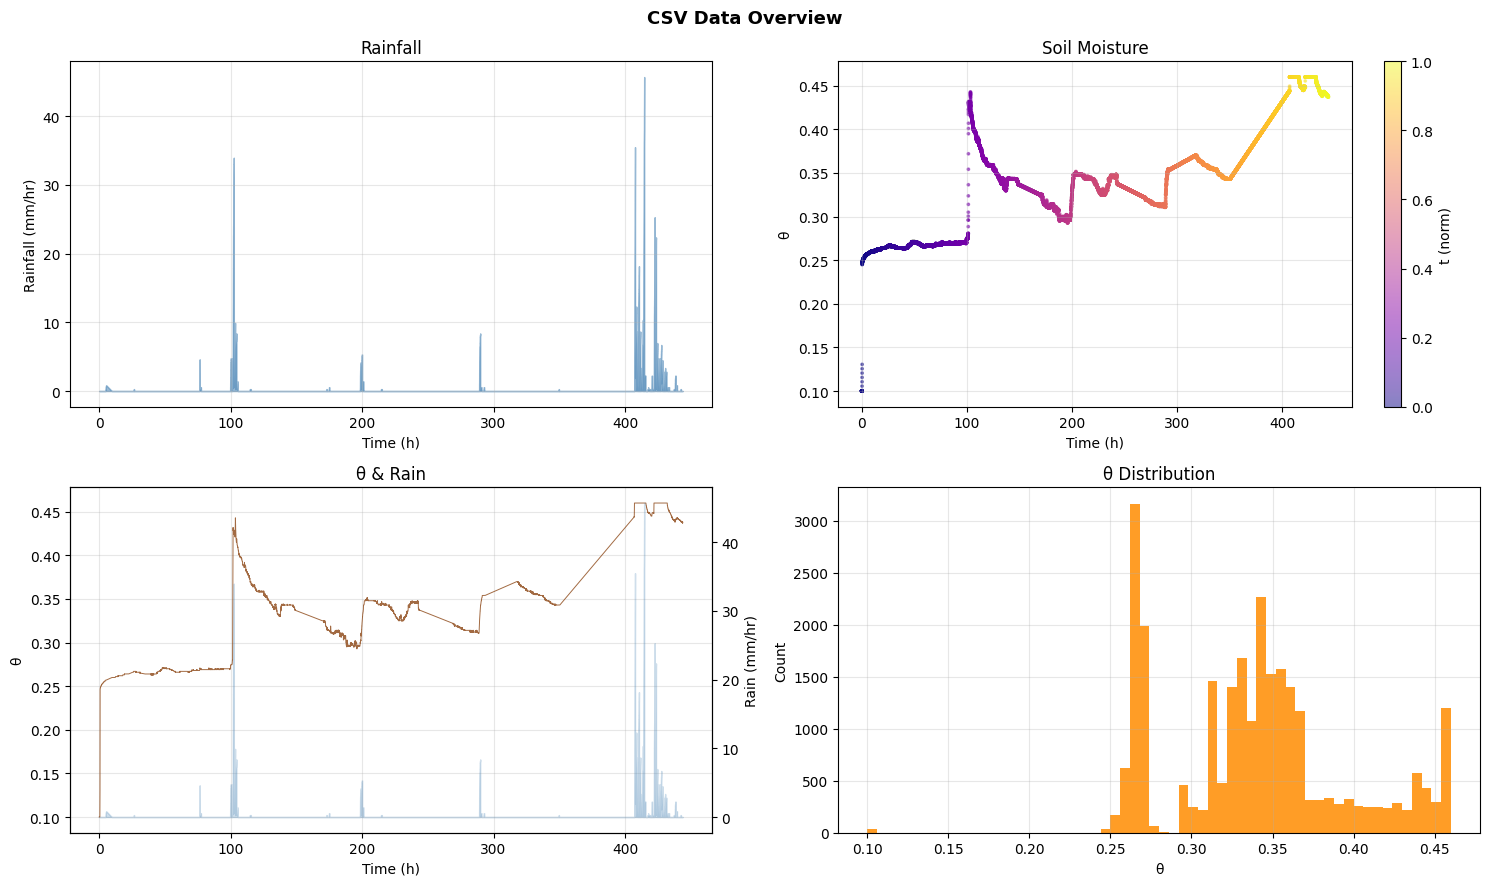


[Inverse PINN] Trainable hydraulic parameters initialised:
  alpha  : [0.75, 0.36, 0.15]
  n      : [1.89, 1.56, 1.25]
  Ks     : [1.22e-06, 2.89e-07, 5.56e-08]
  theta_r: [0.065, 0.078, 0.1]
  theta_s: [0.41, 0.43, 0.46]

  [Data]  CSV — 26636 obs  T_MAX=444h
  [z_obs] 3.00–3.00m
  [theta] 0.100–0.460  mean=0.339  std=0.0563
  [Init]  R²=-1.1432  RMSE=0.08237  MAE=0.06705
  [Phase] 1 = data+IC warmup (ep 1–500)
  [Phase] 2 = all losses     (ep 501–5000)
  [lam_m] = 0.5  ← mechanical loss (raised from 0.001 for real u,w)

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
    Ep  Ph      Total       Data      Cons     Hydro        IC        BC       R²      RMSE       MAE
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     1 Ph1   4.259e+01   4.804e-02  1.415e-02  0.000e+00  1.321e+02  0.000e+00   -1.1060    0.08165    0.06642
   250 Ph1   1.0

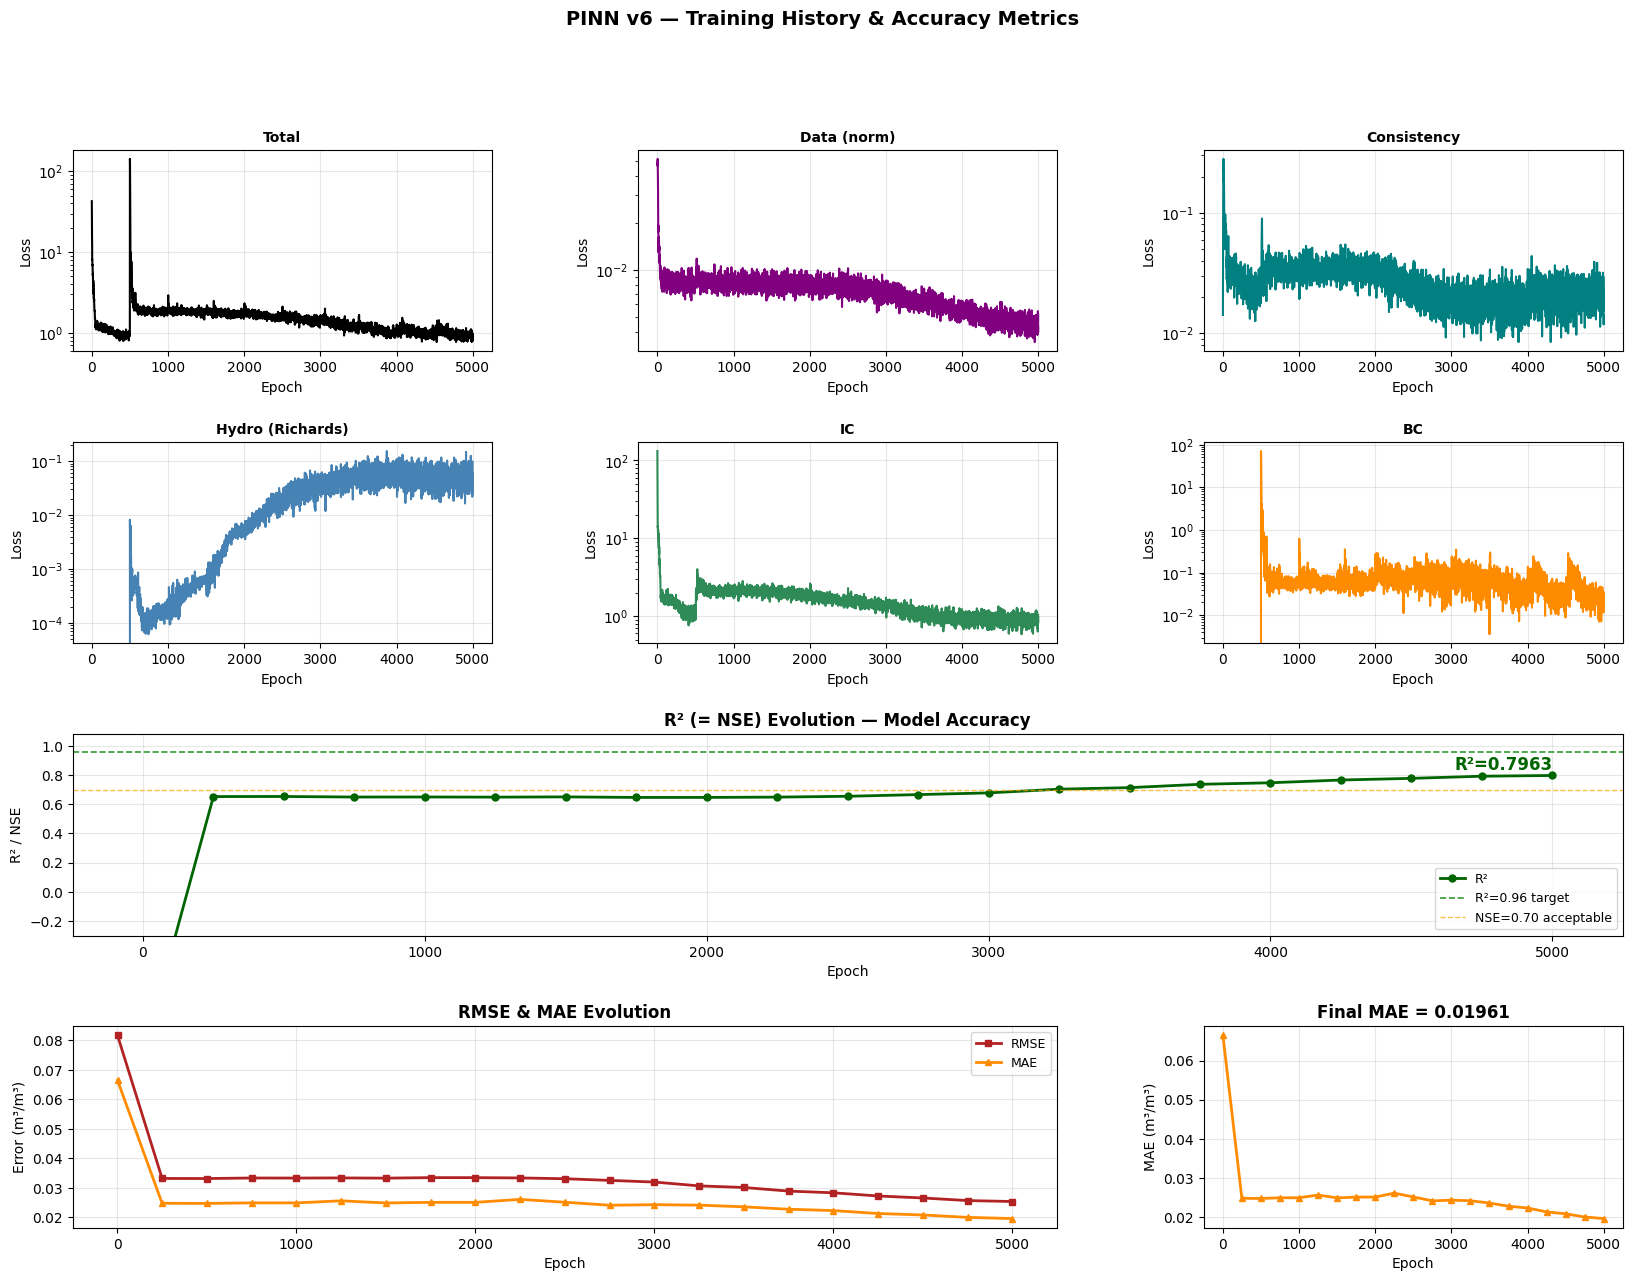

[Plot] Inverse params → inverse_params_v6.png


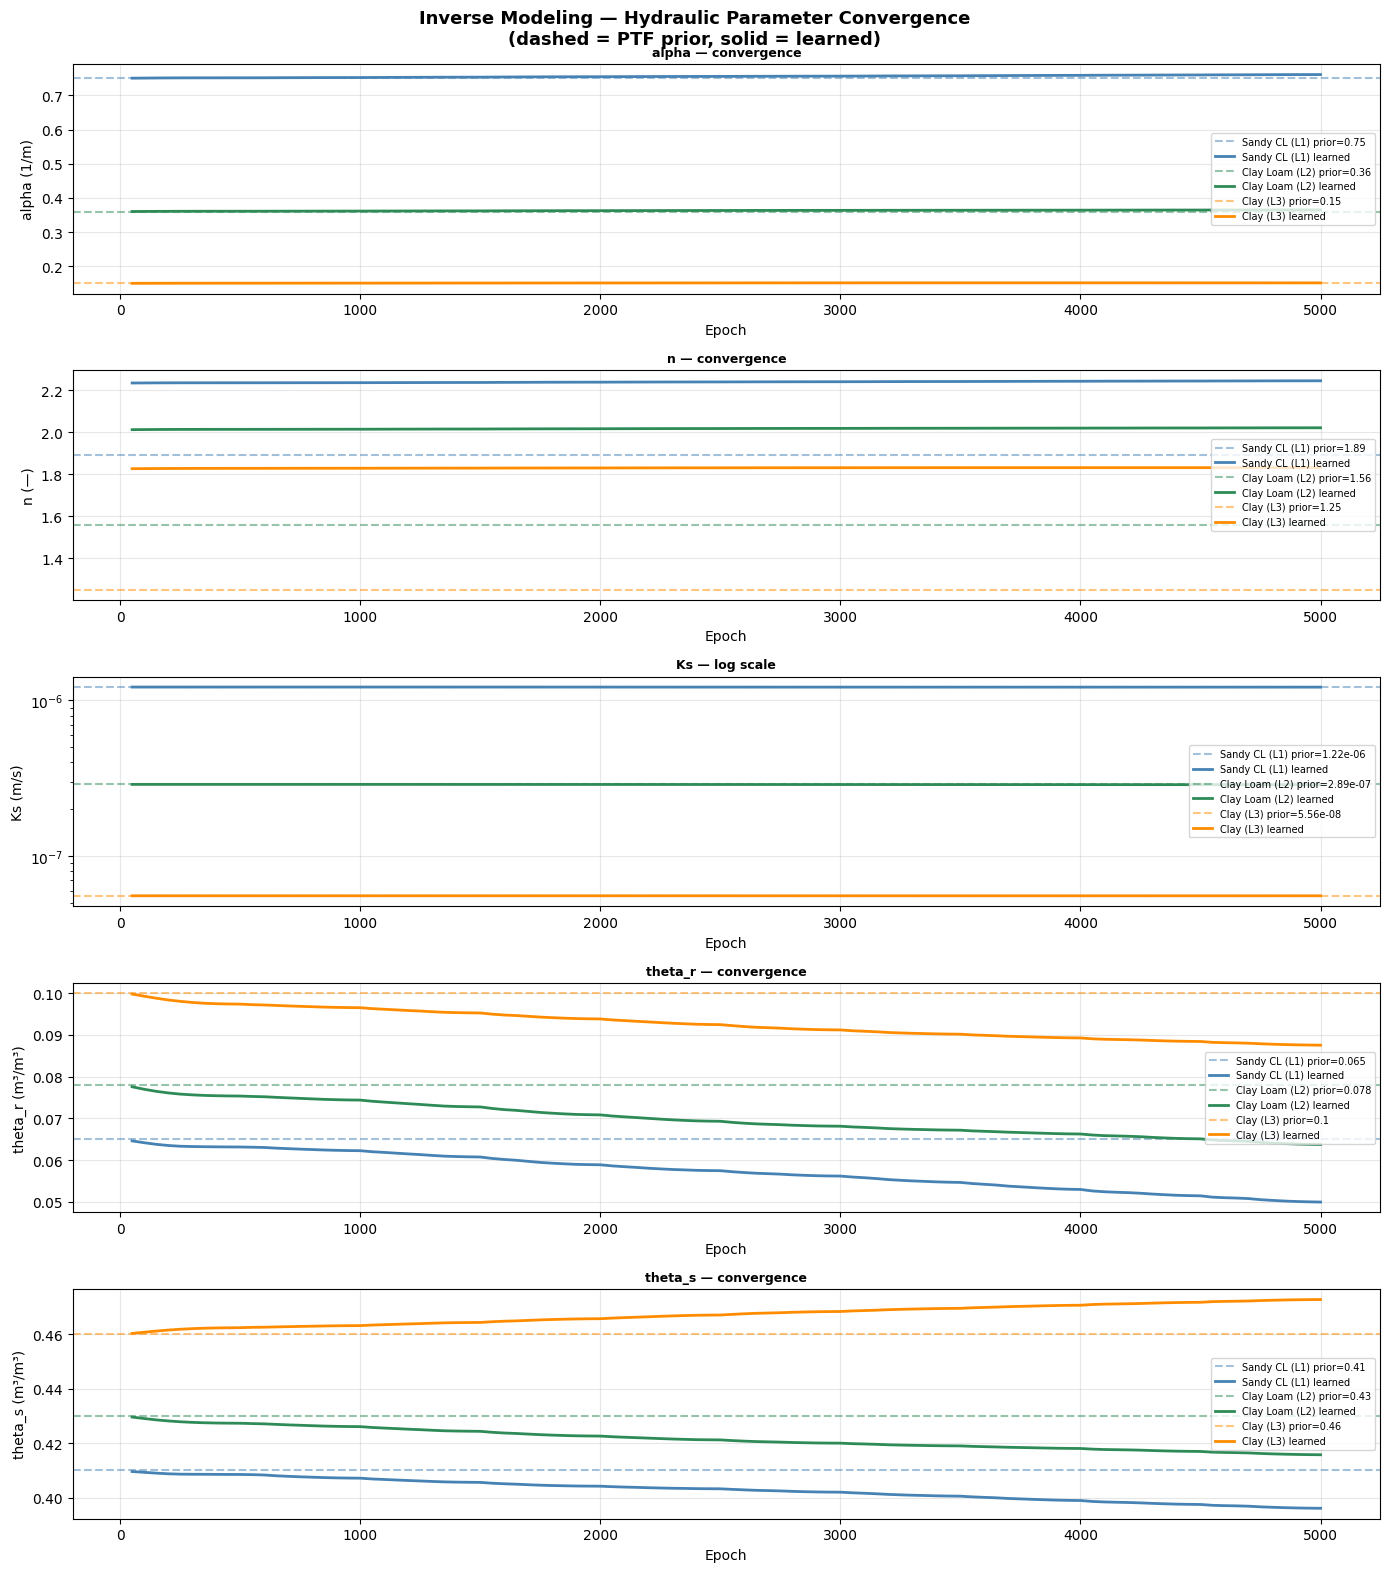

[Plot] Parity → parity_v6.png  R²=0.7963  RMSE=0.02539  MAE=0.01961


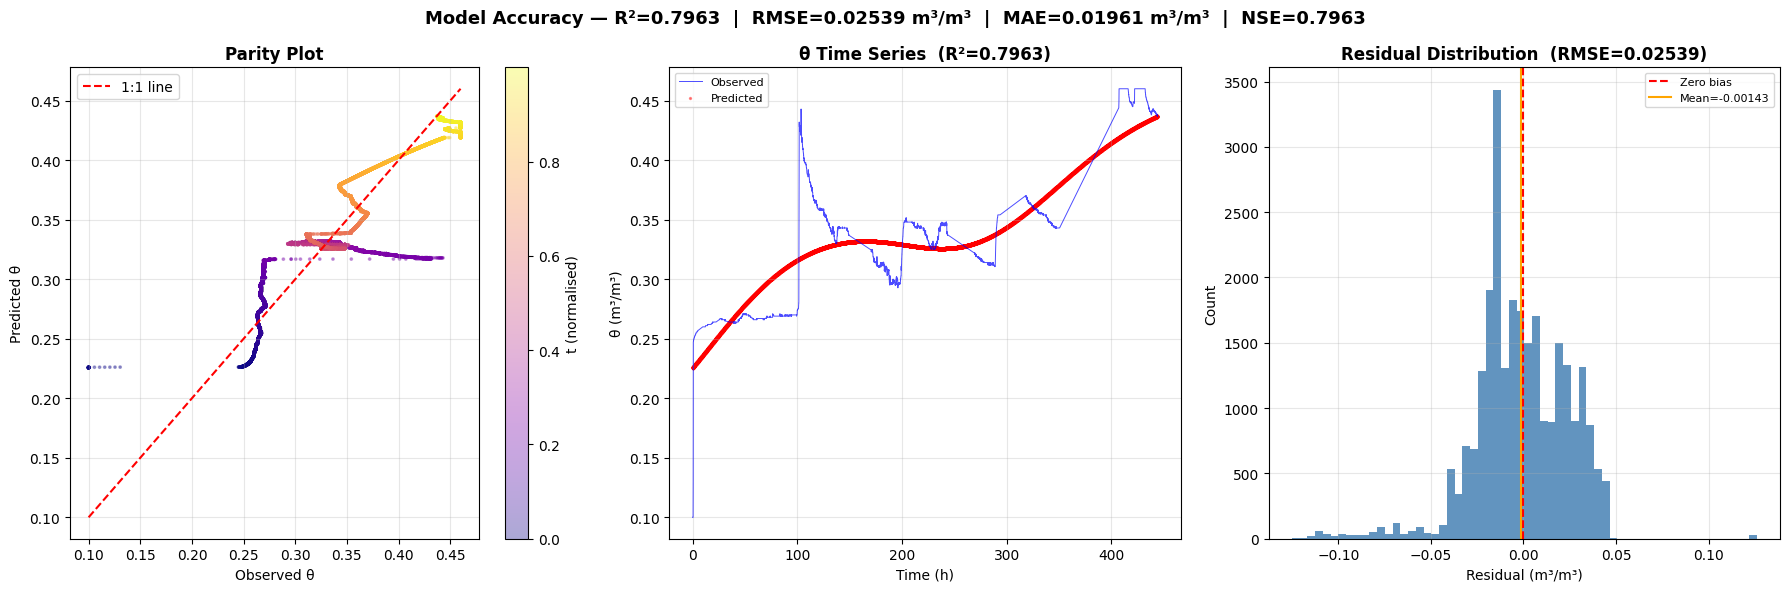

[Plot] Fields → fields_v6.png


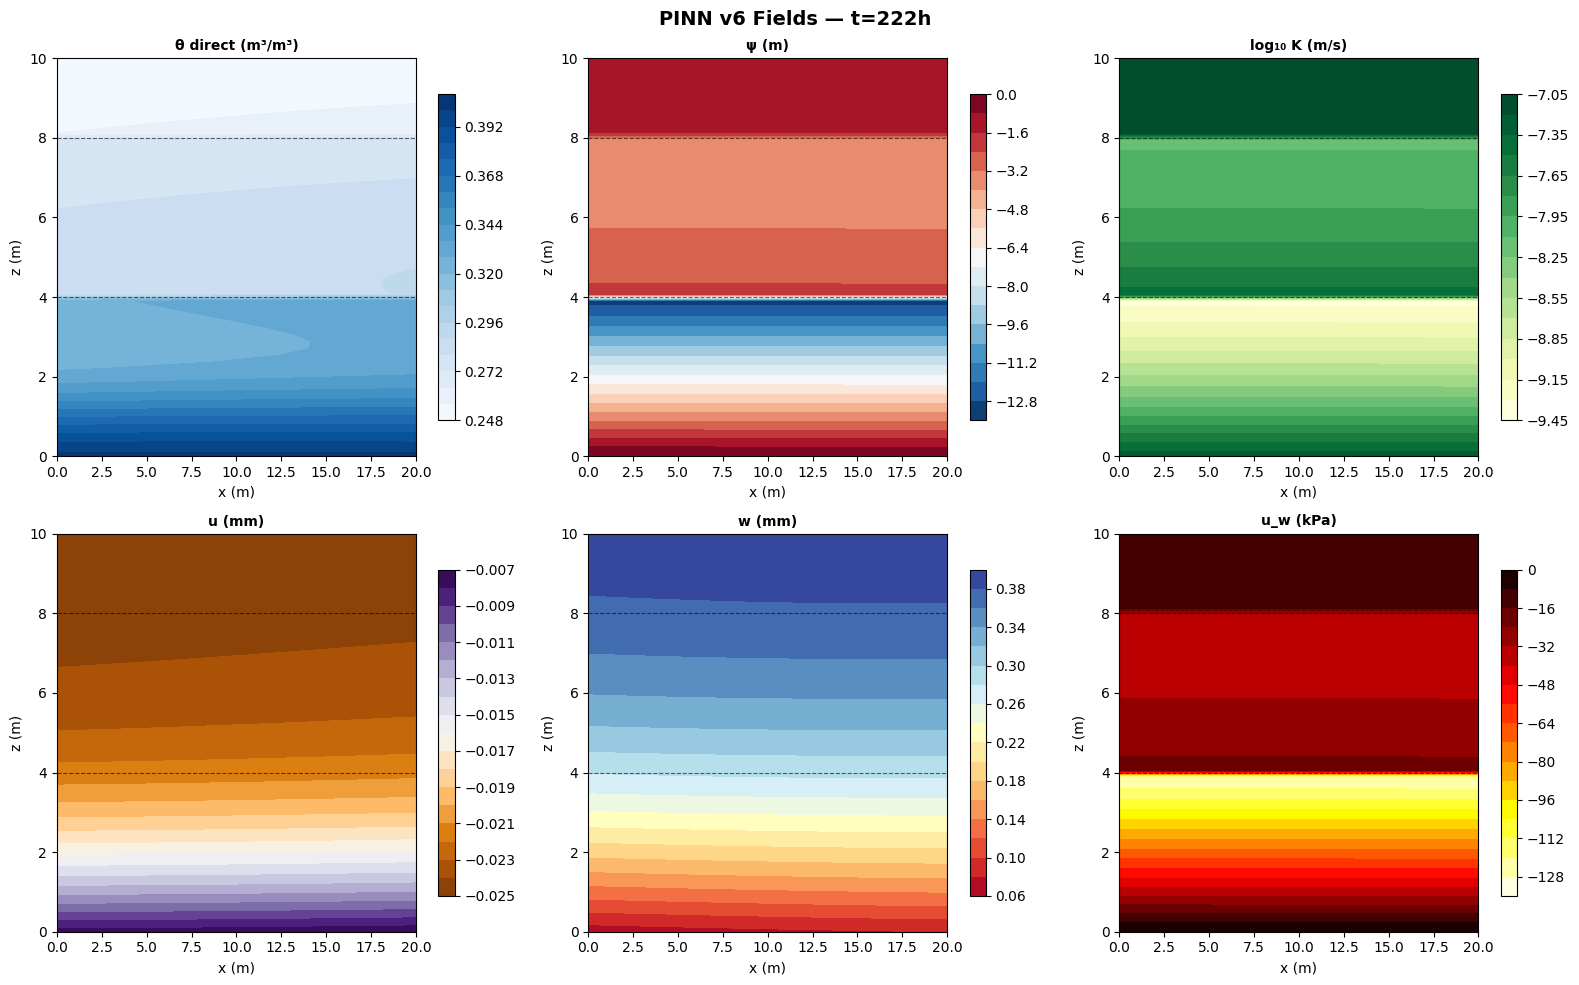


[FoS] Running factor of safety assessment...
[Plot] FoS comparison → fos_v6.png


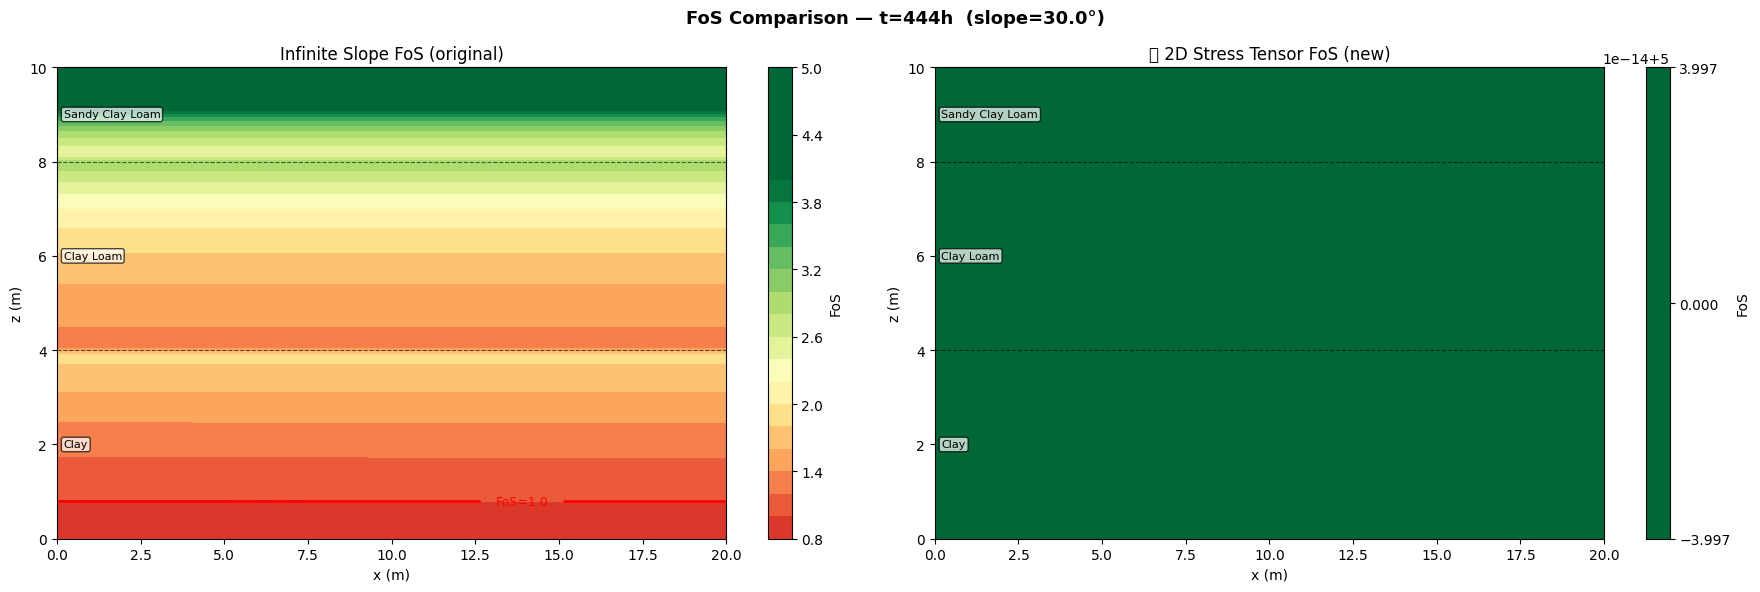

[Plot] FoS evolution → fos_evo_v6.png


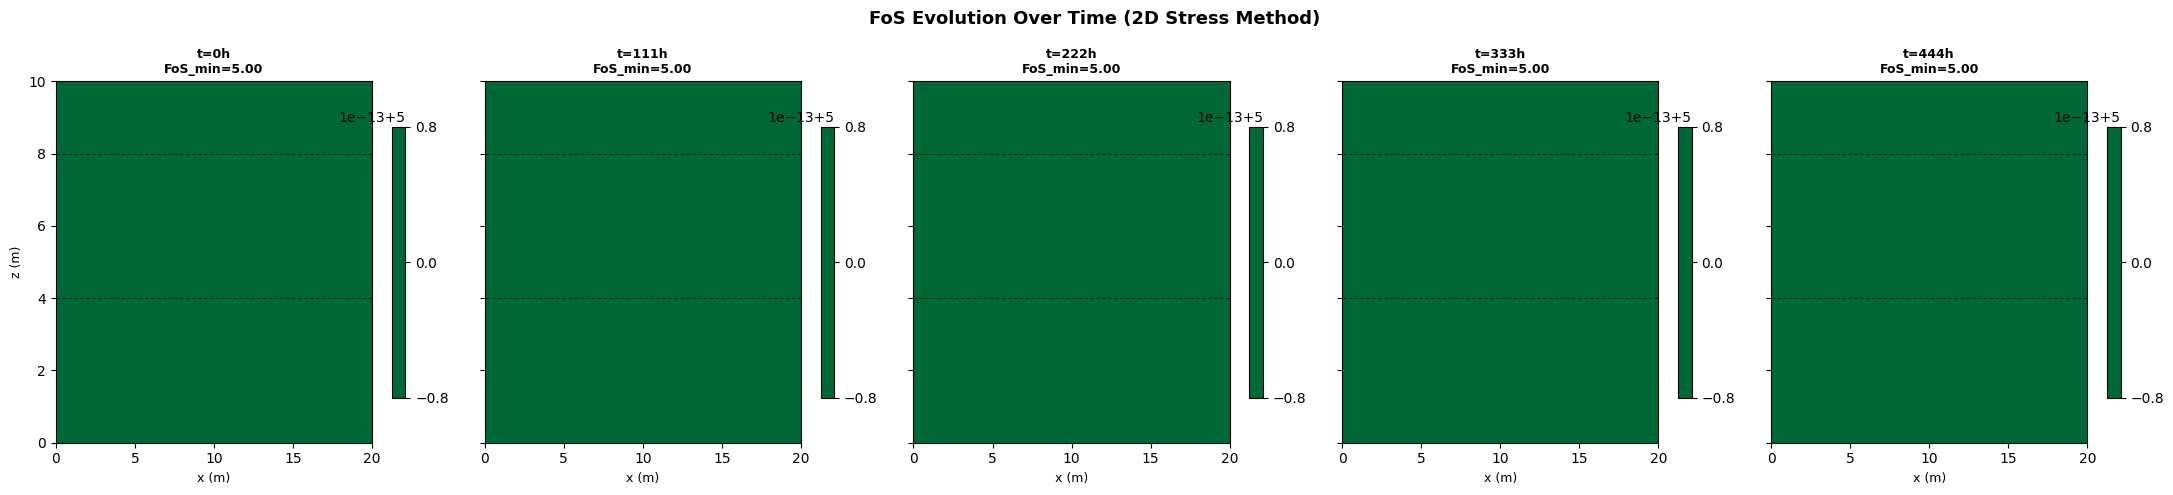

[FoS-Time] Computing FoS at each time step...
  ✓  Slope stable throughout — min FoS = 9.159
[Plot] FoS-time curve → fos_time_curve_v6.png


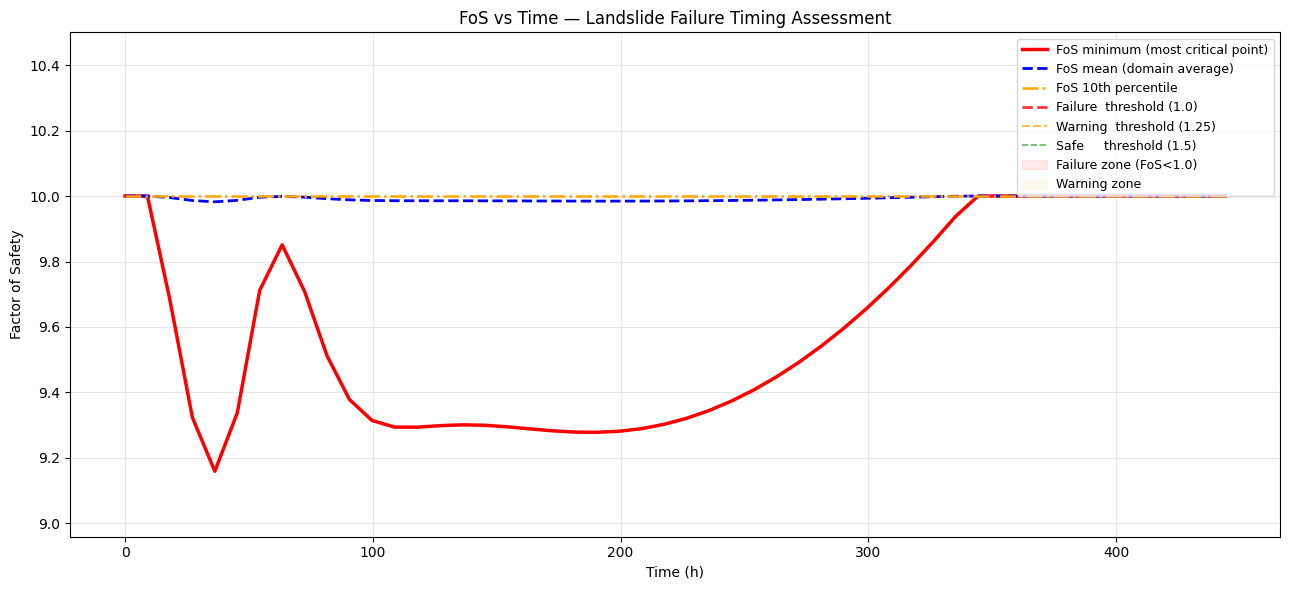

[Plot] Critical surface → critical_surface_v6.png  Failure=0.0%  Warning=0.0%


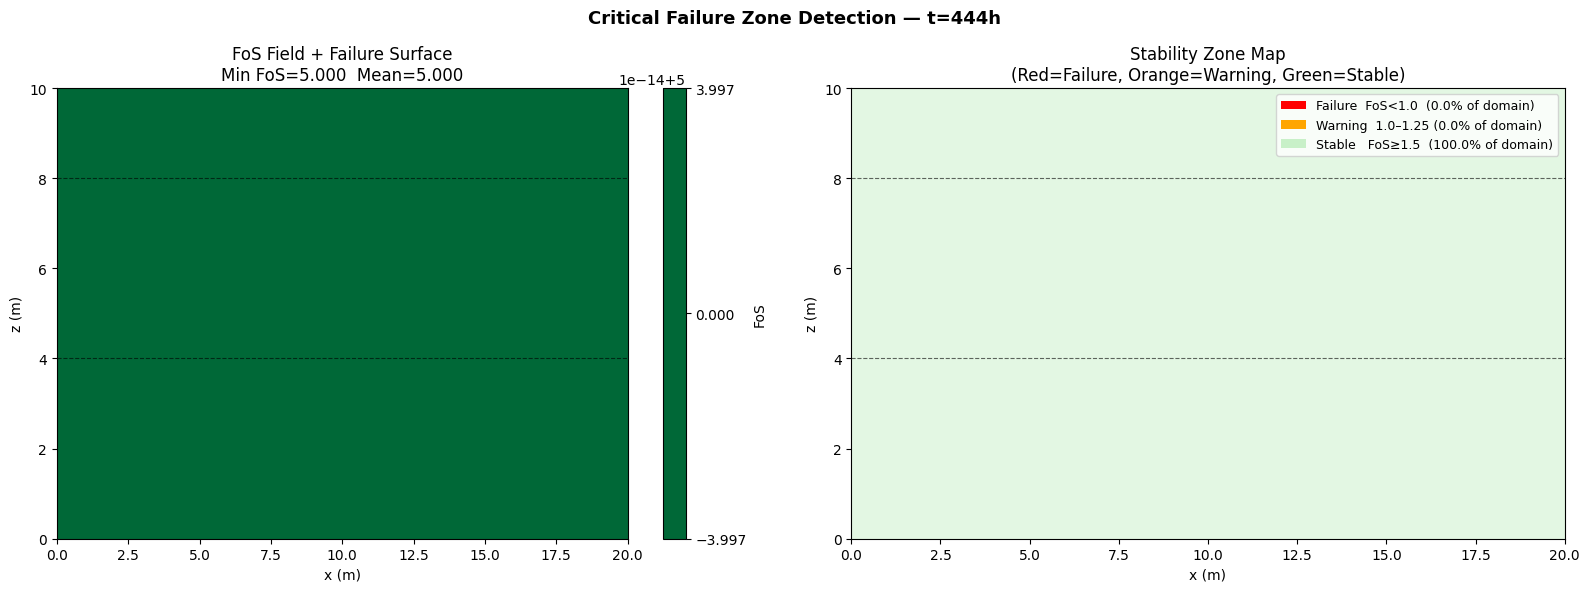

[UQ] Running 30 Monte Carlo FoS samples...
[UQ]  Mean FoS_min=10.000  5th pct=10.000  95th pct=10.000
[UQ]  Max FoS uncertainty (std) = 0.0000
[Plot] FoS uncertainty → fos_uncertainty_v6.png


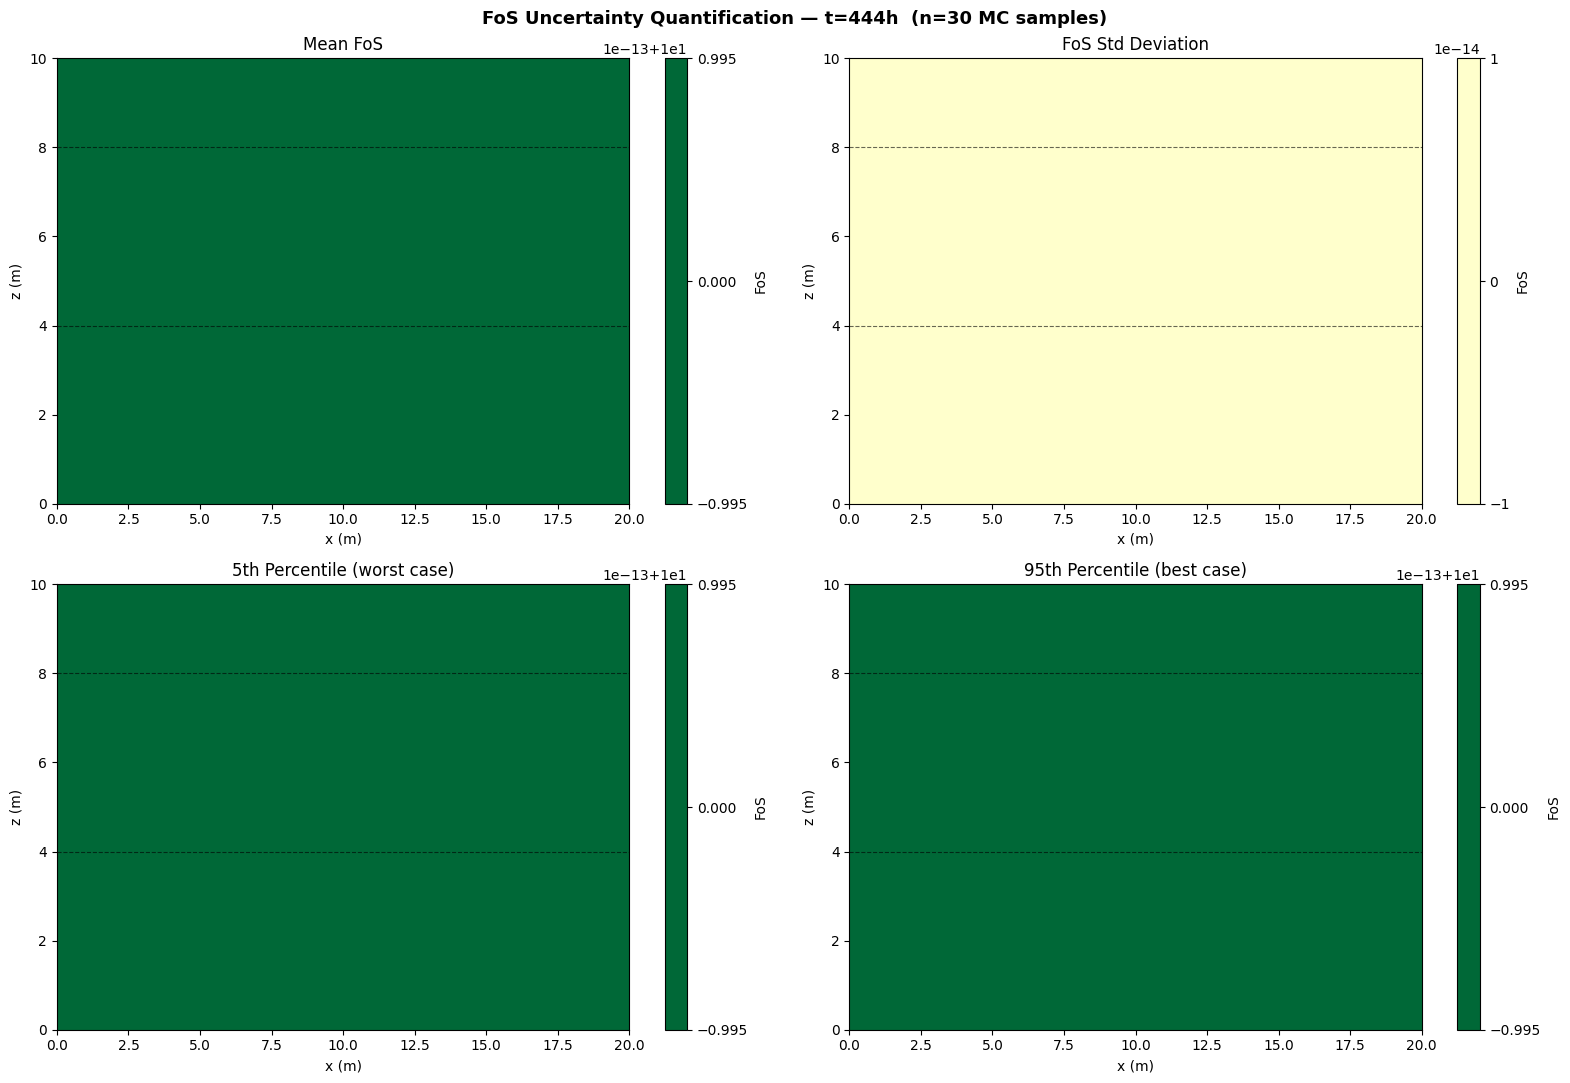


═════════════════════════════════════════════════════════════════
  v7 NEW: 60-MINUTE EARLY WARNING SYSTEM
═════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  🟢  LANDSLIDE EARLY WARNING SYSTEM
  Current time : t = 333.0 h
  Forecast to  : t = 334.0 h  (+60 min)
════════════════════════════════════════════════════════════
  Metric                              Value
  ──────────────────────────────────────────
  Current FoS_min                     9.918  🟢
  Forecast FoS_min (PINN)             9.927
  Forecast FoS_min (Trend)            9.927
  Forecast FoS_min (Ensemble)         9.927  🟢
  dFoS/dt                           +0.0086  /h
  ──────────────────────────────────────────
  ALERT LEVEL : 🟢  GREEN  —  STABLE — slope is safe
════════════════════════════════════════════════════════════
[Dashboard] Building 60-min early warning dashboard at t=333.0h...


NameError: name 'priority' is not defined

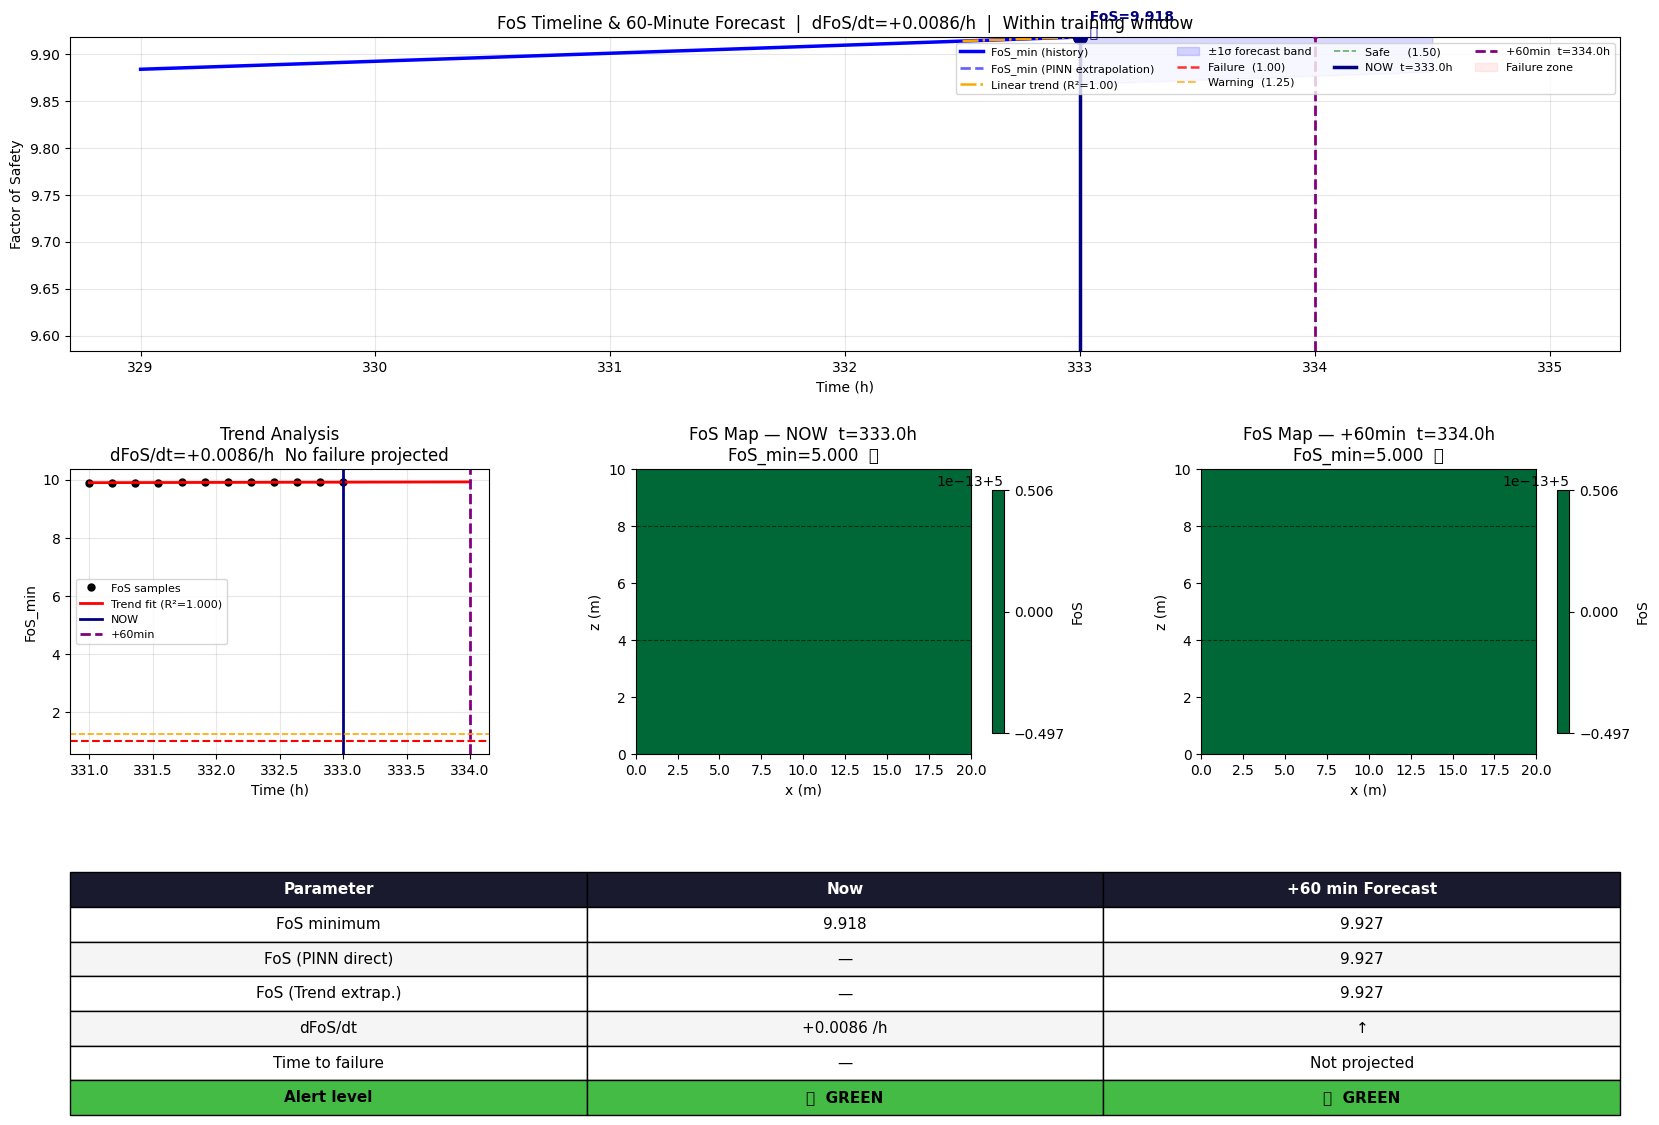

In [1]:
import os
import warnings
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from collections import defaultdict
from torch.autograd import grad as autograd_grad

warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Device] {device}")

# ── Domain ────────────────────────────────────────────────────
X_MAX       = 20.0
Z_MAX       = 10.0
T_MAX       = 24.0
SLOPE_ANGLE = 30.0
RHO_W       = 1000.0
G_ACC       = 9.81
E_REF       = 1.0e6

# ── CSV Column Mappings ───────────────────────────────────────
CSV_FILE    = "/content/label_109_EMA_optimized_PINN.csv"

COL_TIME      = "timestamp"
COL_GEO       = "geo"
COL_DEPTH     = "temp"
COL_RAINFALL  = "rain"
COL_SOIL      = "soil"
RAINFALL_UNIT = "mm/hr"

SINGLE_DEPTH_SENSOR = False
DEPTH_POS_DOWN      = True
GEO_IS_LATLON       = False

TIMESTAMP_FORMATS = [
    "%m/%d/%Y %H:%M",
    "%d/%m/%Y %H:%M", "%d/%m/%Y %H:%M:%S", "%d-%m-%Y %H:%M",
    "%Y-%m-%d %H:%M", "%Y-%m-%d %H:%M:%S", "%m/%d/%Y %H:%M:%S",
]

# ── Soil layers ───────────────────────────────────────────────
SOIL = {
    1: dict(z_lo=8.0,  z_hi=10.0,
            theta_r=0.065, theta_s=0.410, alpha=0.75, n=1.89,
            Ks=1.22e-6,  E=5.0e6,  nu=0.30, rho_b=1600.0,
            c_prime=10.0e3, phi_prime=30.0),
    2: dict(z_lo=4.0,  z_hi=8.0,
            theta_r=0.078, theta_s=0.430, alpha=0.36, n=1.56,
            Ks=2.89e-7,  E=8.0e6,  nu=0.35, rho_b=1700.0,
            c_prime=15.0e3, phi_prime=25.0),
    3: dict(z_lo=0.0,  z_hi=4.0,
            theta_r=0.100, theta_s=0.460, alpha=0.15, n=1.25,
            Ks=5.56e-8,  E=15.0e6, nu=0.40, rho_b=1800.0,
            c_prime=20.0e3, phi_prime=20.0),
}

THETA_CLIP_LO = SOIL[3]["theta_r"]
THETA_CLIP_HI = SOIL[3]["theta_s"]

PARAM_BOUNDS = {
    "alpha":   [(0.01, 3.0),  (0.01, 2.0),  (0.01, 1.0)],
    "n":       [(1.10, 3.0),  (1.05, 2.5),  (1.01, 2.0)],
    "Ks":      [(1e-8, 1e-4), (1e-9, 1e-5), (1e-10, 1e-6)],
    "theta_r": [(0.01, 0.15), (0.01, 0.15), (0.05, 0.20)],
    "theta_s": [(0.30, 0.60), (0.30, 0.60), (0.30, 0.60)],
}


# ── Layer parameter lookups ───────────────────────────────────
def _lp_fixed(z_norm, key):
    z_m = z_norm * Z_MAX
    v1 = float(SOIL[1][key]); v2 = float(SOIL[2][key]); v3 = float(SOIL[3][key])
    return torch.where(z_m >= 8.0, v1 * torch.ones_like(z_m),
           torch.where(z_m >= 4.0, v2 * torch.ones_like(z_m),
                                   v3 * torch.ones_like(z_m)))


def _lp_trainable(z_norm, key, params):
    z_m = z_norm * Z_MAX
    v1 = params[key][0]; v2 = params[key][1]; v3 = params[key][2]
    return torch.where(z_m >= 8.0, v1.expand_as(z_m),
           torch.where(z_m >= 4.0, v2.expand_as(z_m),
                                   v3.expand_as(z_m)))


def _lp(z, key, params=None):
    if params is not None:
        return _lp_trainable(z, key, params)
    return _lp_fixed(z, key)


# ── Van Genuchten ─────────────────────────────────────────────
def vg_Se(psi, z, params=None):
    alpha = _lp(z, "alpha", params); n = _lp(z, "n", params)
    m = 1.0 - 1.0 / n
    arg = torch.clamp(alpha * torch.abs(psi), min=0.0)
    Se  = 1.0 / (1.0 + arg.pow(n)).pow(m)
    Se  = torch.where(psi >= 0.0, torch.ones_like(psi), Se)
    return torch.clamp(Se, min=1e-6, max=1.0 - 1e-6)


def vg_theta(psi, z, params=None):
    return (_lp(z, "theta_r", params)
            + vg_Se(psi, z, params) * (_lp(z, "theta_s", params)
                                       - _lp(z, "theta_r", params)))


def vg_K(psi, z, params=None):
    Ks = _lp(z, "Ks", params); n = _lp(z, "n", params)
    m  = 1.0 - 1.0 / n
    Se = vg_Se(psi, z, params)
    Se_c  = torch.clamp(Se, min=1e-6, max=1.0 - 1e-6)
    inner = torch.clamp(1.0 - Se_c.pow(1.0 / m), min=0.0)
    K     = Ks * Se.pow(0.5) * (1.0 - inner.pow(m)).pow(2.0)
    return torch.clamp(K, min=1e-15, max=1e-2)


def dtheta_dpsi(psi, z, params=None):
    alpha = _lp(z, "alpha", params); n = _lp(z, "n", params)
    m = 1.0 - 1.0 / n
    dts   = _lp(z, "theta_s", params) - _lp(z, "theta_r", params)
    arg   = torch.clamp(alpha * torch.abs(psi), min=0.0)
    denom = 1.0 + arg.pow(n)
    C     = dts * m * n * alpha * arg.pow(n - 1.0) / denom.pow(m + 1.0)
    C     = torch.where(psi >= 0.0, torch.zeros_like(psi), C)
    return torch.clamp(C, min=0.0, max=10.0)


def inv_vg_psi(theta, z, params=None):
    alpha   = _lp(z, "alpha",   params); n = _lp(z, "n", params)
    m       = 1.0 - 1.0 / n
    theta_r = _lp(z, "theta_r", params); theta_s = _lp(z, "theta_s", params)
    Se      = torch.clamp((theta - theta_r) / (theta_s - theta_r), min=1e-6, max=1.0 - 1e-6)
    inner   = torch.clamp(Se.pow(-1.0 / m) - 1.0, min=0.0)
    psi     = -(1.0 / alpha) * inner.pow(1.0 / n)
    return torch.clamp(psi, min=-500.0, max=0.0)


# ── Elasticity ────────────────────────────────────────────────
def lame(z):
    E = _lp(z, "E"); nu = _lp(z, "nu")
    lam = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
    mu  = E / (2.0 * (1.0 + nu))
    return lam, mu


def _grad(y, v):
    return autograd_grad(y, v, grad_outputs=torch.ones_like(y),
                         create_graph=True, retain_graph=True)[0]


def stress_2d(u, w, x, z):
    eps_xx = _grad(u, x); eps_zz = _grad(w, z)
    gamma  = _grad(u, z) + _grad(w, x)
    lam_t, mu_t = lame(z)
    dil = eps_xx + eps_zz
    sxx = (lam_t * dil + 2.0 * mu_t * eps_xx) / E_REF
    szz = (lam_t * dil + 2.0 * mu_t * eps_zz) / E_REF
    txz = (mu_t * gamma)                       / E_REF
    return sxx, szz, txz


# ── Neural Network ────────────────────────────────────────────
class PINN(nn.Module):
    def __init__(self, hidden=6, width=128):
        super().__init__()
        layers = [nn.Linear(3, width), nn.Tanh()]
        for _ in range(hidden - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        self.trunk      = nn.Sequential(*layers)
        self.head_psi   = nn.Linear(width, 1)
        self.head_disp  = nn.Linear(width, 2)
        self.head_theta = nn.Linear(width, 1)
        self._init_weights()

        def _init_param(key):
            vals = [SOIL[i][key] for i in [1, 2, 3]]
            return nn.Parameter(torch.tensor(vals, dtype=torch.float32))

        self._log_alpha   = nn.Parameter(torch.log(_init_param("alpha").data))
        self._log_Ks      = nn.Parameter(torch.log(_init_param("Ks").data))
        self._raw_n       = nn.Parameter(_init_param("n").data - 1.0)
        self._raw_theta_r = nn.Parameter(_init_param("theta_r").data)
        self._raw_theta_s = nn.Parameter(_init_param("theta_s").data)

        print("\n[Inverse PINN] Trainable hydraulic parameters initialised:")
        print(f"  alpha  : {[SOIL[i]['alpha']  for i in [1,2,3]]}")
        print(f"  n      : {[SOIL[i]['n']      for i in [1,2,3]]}")
        print(f"  Ks     : {[SOIL[i]['Ks']     for i in [1,2,3]]}")
        print(f"  theta_r: {[SOIL[i]['theta_r'] for i in [1,2,3]]}")
        print(f"  theta_s: {[SOIL[i]['theta_s'] for i in [1,2,3]]}\n")

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)

    @property
    def hydro_params(self):
        alpha   = torch.exp(self._log_alpha)
        Ks      = torch.exp(self._log_Ks)
        n       = 1.0 + torch.nn.functional.softplus(self._raw_n)
        theta_r = torch.clamp(self._raw_theta_r, min=0.01, max=0.25)
        theta_s = torch.clamp(self._raw_theta_s, min=0.10, max=0.65)
        theta_s = torch.max(theta_s, theta_r.detach() + 0.05)
        return {"alpha": alpha, "n": n, "Ks": Ks, "theta_r": theta_r, "theta_s": theta_s}

    def clamp_params_(self):
        with torch.no_grad():
            bounds = PARAM_BOUNDS
            for li in range(3):
                lo, hi = bounds["alpha"][li]
                self._log_alpha.data[li].clamp_(np.log(lo), np.log(hi))
                lo, hi = bounds["Ks"][li]
                self._log_Ks.data[li].clamp_(np.log(lo), np.log(hi))
                lo, hi = bounds["n"][li]
                self._raw_n.data[li].clamp_(lo - 1.0, hi - 1.0)
                lo, hi = bounds["theta_r"][li]
                self._raw_theta_r.data[li].clamp_(lo, hi)
                lo, hi = bounds["theta_s"][li]
                self._raw_theta_s.data[li].clamp_(lo, hi)

    def get_learned_params(self):
        p = self.hydro_params
        return {k: v.detach().cpu().numpy() for k, v in p.items()}

    def forward(self, x, z, t):
        feat    = self.trunk(torch.cat([x, z, t], dim=1))
        z_m     = z * Z_MAX
        raw_psi = self.head_psi(feat)
        scale   = torch.where(z_m >= 8.0,  3.0 * torch.ones_like(z_m),
                  torch.where(z_m >= 4.0,  7.0 * torch.ones_like(z_m),
                                           25.0 * torch.ones_like(z_m)))
        shift   = torch.where(z_m >= 8.0, -1.5 * torch.ones_like(z_m),
                  torch.where(z_m >= 4.0, -4.0 * torch.ones_like(z_m),
                                          -20.0 * torch.ones_like(z_m)))
        psi   = scale * torch.tanh(raw_psi) + shift
        raw_d = self.head_disp(feat)
        u     = raw_d[:, 0:1] * 1e-3
        w     = raw_d[:, 1:2] * 1e-3
        p       = self.hydro_params
        raw_th  = self.head_theta(feat)
        theta_r = _lp(z, "theta_r", p)
        theta_s = _lp(z, "theta_s", p)
        theta_d = theta_r + (theta_s - theta_r) * torch.sigmoid(raw_th)
        return psi, u, w, theta_d


# ── Collocation points ────────────────────────────────────────
def sample_pts(n_int, n_bc, n_ic):
    def rn(n): return torch.rand(n, 1, device=device)
    def ze(n): return torch.zeros(n, 1, device=device)
    def on(n): return torch.ones(n, 1, device=device)
    def rq(*ts): return tuple(t.requires_grad_(True) for t in ts)
    return dict(
        int=rq(rn(n_int), rn(n_int), rn(n_int)),
        ic =rq(rn(n_ic),  rn(n_ic),  ze(n_ic)),
        top=rq(rn(n_bc),  on(n_bc),  rn(n_bc)),
        bot=rq(rn(n_bc),  ze(n_bc),  rn(n_bc)),
        lft=rq(ze(n_bc),  rn(n_bc),  rn(n_bc)),
        rgt=rq(on(n_bc),  rn(n_bc),  rn(n_bc)),
    )


def psi_initial(z_norm):
    return -(Z_MAX - z_norm * Z_MAX) * 0.4


_q_rain_fn = None


def q_rain_fallback(t_norm):
    return 1.94e-6 * torch.ones_like(t_norm)


def get_q_rain():
    return _q_rain_fn if _q_rain_fn is not None else q_rain_fallback


# ── Metrics ───────────────────────────────────────────────────
def compute_metrics(model, x_obs, z_obs, t_obs, theta_obs):
    with torch.no_grad():
        _, _, _, theta_d = model(x_obs, z_obs, t_obs)
        obs = theta_obs; pred = theta_d
        ss_res = torch.sum((pred - obs) ** 2)
        ss_tot = torch.sum((obs - obs.mean()) ** 2)
        r2   = (1.0 - ss_res / ss_tot).item() if ss_tot > 1e-12 else float("nan")
        rmse = torch.sqrt(torch.mean((pred - obs) ** 2)).item()
        mae  = torch.mean(torch.abs(pred - obs)).item()
        nse  = r2
    return {"R2": r2, "RMSE": rmse, "MAE": mae, "NSE": nse}


def compute_r2(model, x_obs, z_obs, t_obs, theta_obs):
    return compute_metrics(model, x_obs, z_obs, t_obs, theta_obs)["R2"]


# ── PDE Losses ────────────────────────────────────────────────
def safe_mean_sq(residual, name=""):
    val = torch.mean(residual ** 2)
    if not torch.isfinite(val):
        print(f"  ⚠  NaN/Inf in '{name}' — skipping")
        return torch.tensor(0.0, device=residual.device, requires_grad=True)
    return val


def loss_richards(model, x, z, t):
    p = model.hydro_params
    psi, _, _, _ = model(x, z, t)
    K  = vg_K(psi, z, p); C = dtheta_dpsi(psi, z, p)
    Kx = K * _grad(psi, x); Kz = K * (_grad(psi, z) + 1.0)
    res = C * _grad(psi, t) - _grad(Kx, x) - _grad(Kz, z)
    return safe_mean_sq(res, "richards")


def loss_ic(model, x, z, t):
    psi, u, w, _ = model(x, z, t)
    return (safe_mean_sq(psi - psi_initial(z), "ic_psi")
          + safe_mean_sq(u, "ic_u") + safe_mean_sq(w, "ic_w"))


def loss_bc_top(model, x, z, t):
    p = model.hydro_params
    psi, u, w, _ = model(x, z, t)
    K      = vg_K(psi, z, p)
    q_pred = -K * (_grad(psi, z) + 1.0)
    l_flux = safe_mean_sq(q_pred - get_q_rain()(t), "bc_top_flux")
    _, szz, txz = stress_2d(u, w, x, z)
    return l_flux + 0.05 * (safe_mean_sq(szz, "szz") + safe_mean_sq(txz, "txz"))


def loss_bc_bot(model, x, z, t):
    psi, u, w, _ = model(x, z, t)
    return (safe_mean_sq(psi, "bc_bot_psi")
          + safe_mean_sq(u, "bc_bot_u") + safe_mean_sq(w, "bc_bot_w"))


def loss_bc_sides(model, xl, zl, tl, xr, zr, tr):
    pl, _, _, _ = model(xl, zl, tl); pr, _, _, _ = model(xr, zr, tr)
    return (safe_mean_sq(_grad(pl, xl), "side_l")
          + safe_mean_sq(_grad(pr, xr), "side_r"))


def loss_mech(model, x, z, t):
    _, u, w, _ = model(x, z, t)
    sxx, szz, txz = stress_2d(u, w, x, z)
    body = _lp(z, "rho_b") * G_ACC / E_REF
    return (safe_mean_sq(_grad(sxx, x) + _grad(txz, z),        "mech_x")
          + safe_mean_sq(_grad(txz, x) + _grad(szz, z) + body, "mech_z"))


def loss_data(model, x_obs, z_obs, t_obs, theta_obs):
    p = model.hydro_params
    _, _, _, theta_d = model(x_obs, z_obs, t_obs)
    dts = _lp(z_obs, "theta_s", p) - _lp(z_obs, "theta_r", p)
    normalised_res = (theta_d - theta_obs) / (dts + 1e-6)
    return safe_mean_sq(normalised_res, "data_theta_norm")


def loss_consistency(model, x, z, t):
    p = model.hydro_params
    psi, _, _, theta_d = model(x, z, t)
    psi_target = inv_vg_psi(theta_d.detach(), z, p)
    psi_scale  = torch.where(z * Z_MAX >= 8.0,  3.0 * torch.ones_like(z),
                 torch.where(z * Z_MAX >= 4.0, 10.0 * torch.ones_like(z),
                                               50.0 * torch.ones_like(z)))
    res = (psi - psi_target) / (psi_scale + 1e-6)
    return safe_mean_sq(res, "consistency")


def synthetic_sensors(n=300):
    xo = torch.rand(n, 1, device=device)
    zo = torch.rand(n, 1, device=device)
    to = torch.rand(n, 1, device=device)
    tr = _lp(zo, "theta_r"); ts = _lp(zo, "theta_s")
    t_h = to * T_MAX
    sat = 0.3 + 0.5 * torch.exp(-0.5 * ((t_h - T_MAX * 0.375) / (T_MAX * 0.1)) ** 2)
    th  = torch.clamp(tr + sat * (ts - tr) + 0.005 * torch.randn_like(tr), min=tr, max=ts)
    return xo, zo, to, th


# ── Training ──────────────────────────────────────────────────
def train(warmup_epochs=500, total_epochs=5000, lr=2e-4,
          n_int=100, n_bc=150, n_ic=200,
          lam_h=1.0,
          lam_m=0.5,       # ✅ FIX: raised from 0.001 → 0.5 so u,w are physically meaningful
          lam_ic=0.5,
          lam_bc=2.0, lam_data=60.0, lam_cons=5.0,
          csv_loader=None, print_every=250):

    global _q_rain_fn
    model = PINN(hidden=6, width=128).to(device)

    net_params   = list(model.trunk.parameters()) + \
                   list(model.head_psi.parameters()) + \
                   list(model.head_disp.parameters()) + \
                   list(model.head_theta.parameters())
    hydro_params = [model._log_alpha, model._log_Ks,
                    model._raw_n, model._raw_theta_r, model._raw_theta_s]

    opt = torch.optim.Adam([
        {"params": net_params,   "lr": lr,        "weight_decay": 1e-5},
        {"params": hydro_params, "lr": lr * 0.05, "weight_decay": 0.0},
    ])
    sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                opt, T_0=500, T_mult=1, eta_min=5e-7)

    use_csv = csv_loader is not None and getattr(csv_loader, "_loaded", False)
    if use_csv:
        csv_loader.to(device)
        xo  = csv_loader.x_obs_norm; zo  = csv_loader.z_obs_norm
        to_ = csv_loader.t_obs_norm; tho = csv_loader.theta_obs
        _q_rain_fn = csv_loader.make_q_rain_fn()
        print(f"  [Data]  CSV — {len(tho)} obs  T_MAX={T_MAX:.0f}h")
        print(f"  [z_obs] {(zo*Z_MAX).min().item():.2f}–{(zo*Z_MAX).max().item():.2f}m")
        print(f"  [theta] {tho.min().item():.3f}–{tho.max().item():.3f}  "
              f"mean={tho.mean().item():.3f}  std={tho.std().item():.4f}")
    else:
        xo, zo, to_, tho = synthetic_sensors(300)
        _q_rain_fn = None
        print("  [Data]  Synthetic sensors (no CSV)")

    init_m = compute_metrics(model, xo, zo, to_, tho)
    print(f"  [Init]  R²={init_m['R2']:.4f}  RMSE={init_m['RMSE']:.5f}  MAE={init_m['MAE']:.5f}")
    print(f"  [Phase] 1 = data+IC warmup (ep 1–{warmup_epochs})")
    print(f"  [Phase] 2 = all losses     (ep {warmup_epochs+1}–{total_epochs})")
    print(f"  [lam_m] = {lam_m}  ← mechanical loss (raised from 0.001 for real u,w)")

    hist = defaultdict(list)
    param_hist = defaultdict(list)
    N   = len(tho)
    bar = "─" * 120
    print(f"\n{bar}")
    print(f"{'Ep':>6} {'Ph':>3} {'Total':>10} {'Data':>10} "
          f"{'Cons':>9} {'Hydro':>9} {'IC':>9} {'BC':>9} "
          f"{'R²':>8} {'RMSE':>9} {'MAE':>9}")
    print(bar)

    nan_count = 0
    for ep in range(1, total_epochs + 1):
        opt.zero_grad()
        phase = 1 if ep <= warmup_epochs else 2

        p_pts = sample_pts(n_int, n_bc, n_ic)
        xi, zi, ti = p_pts["int"]; xc, zc, tc = p_pts["ic"]
        xt, zt, tt = p_pts["top"]; xb, zb, tb = p_pts["bot"]
        xl, zl, tl = p_pts["lft"]; xr, zr, tr = p_pts["rgt"]

        idx  = torch.randperm(N, device=device)[:min(N, 512)]
        xob  = xo[idx].requires_grad_(False); zob = zo[idx].requires_grad_(False)
        tob  = to_[idx].requires_grad_(False); thob = tho[idx]

        lD    = loss_data(model, xob, zob, tob, thob)
        lCons = loss_consistency(model, xi, zi, ti)
        lI    = loss_ic(model, xc, zc, tc)

        if phase == 1:
            total = lam_data * lD + lam_cons * lCons + 0.3 * lI
            lH = torch.tensor(0.0); lB = torch.tensor(0.0)
        else:
            lH = loss_richards(model, xi, zi, ti)
            lB = (loss_bc_top  (model, xt, zt, tt)
                + loss_bc_bot  (model, xb, zb, tb)
                + loss_bc_sides(model, xl, zl, tl, xr, zr, tr))
            lM = loss_mech(model, xi, zi, ti)
            total = (lam_data * lD + lam_cons * lCons
                   + lam_ic * lI   + lam_bc * lB
                   + lam_h * lH    + lam_m * lM)

        if not torch.isfinite(total):
            nan_count += 1
            print(f"  ⚠  Ep {ep}: NaN total")
            if nan_count >= 5: print("  ✗  Stopping."); break
            sched.step(); continue

        nan_count = 0
        total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        model.clamp_params_()
        sched.step()

        for k, v in [("total", total.item()), ("D", lD.item()),
                     ("Cons", lCons.item()),
                     ("H", lH if isinstance(lH, float) else lH.item()),
                     ("I", lI.item()),
                     ("B", lB if isinstance(lB, float) else lB.item())]:
            hist[k].append(v)

        if ep % 50 == 0:
            lp = model.get_learned_params()
            for k, v in lp.items():
                param_hist[k].append((ep, v.copy()))

        if ep % print_every == 0 or ep == 1:
            m = compute_metrics(model, xo, zo, to_, tho)
            hist["r2"].append((ep, m["R2"]))
            hist["rmse"].append((ep, m["RMSE"]))
            hist["mae"].append((ep, m["MAE"]))
            lH_v = lH if isinstance(lH, float) else lH.item()
            lB_v = lB if isinstance(lB, float) else lB.item()
            print(f"{ep:>6d} Ph{phase}  {total.item():>10.3e}  {lD.item():>10.3e}  "
                  f"{lCons.item():>9.3e}  {lH_v:>9.3e}  {lI.item():>9.3e}  "
                  f"{lB_v:>9.3e}  "
                  f"{m['R2']:>8.4f}  {m['RMSE']:>9.5f}  {m['MAE']:>9.5f}")

    final_m  = compute_metrics(model, xo, zo, to_, tho)
    lp_final = model.get_learned_params()

    print(f"{bar}")
    print(f"✓  Final  R²={final_m['R2']:.4f}  RMSE={final_m['RMSE']:.5f}  "
          f"MAE={final_m['MAE']:.5f}  NSE={final_m['NSE']:.4f}")
    _print_r2_advice(final_m["R2"])

    print("\n[Inverse Results] Learned vs Prior hydraulic parameters:")
    print(f"{'Param':<10} {'Layer':<12} {'Prior':>12} {'Learned':>12} {'Δ%':>8}")
    print("─" * 56)
    for key in ["alpha", "n", "Ks", "theta_r", "theta_s"]:
        for li, layer_name in enumerate(["Sandy CL", "Clay Loam", "Clay"]):
            prior   = SOIL[li+1][key]
            learned = lp_final[key][li]
            delta   = 100.0 * (learned - prior) / (abs(prior) + 1e-20)
            print(f"  {key:<8} {layer_name:<12} {prior:>12.4e}  {learned:>12.4e}  {delta:>+7.1f}%")
    print("─" * 56)

    hist["param_hist"] = param_hist
    return model, hist, final_m


def _print_r2_advice(r2):
    if r2 >= 0.96:   print("  ✓  Excellent — R² achieved!")
    elif r2 >= 0.85: print("  ✓  Good fit. Try lam_data=60 or more epochs.")
    elif r2 >= 0.60: print("  ⚠  Moderate. Raise lam_data to 60–80, epochs to 8000.")
    else:            print("  ✗  Poor fit. Run plot_parity() to diagnose.")


# ════════════════════════════════════════════════════════════════
#  FACTOR OF SAFETY — ALL THREE METHODS
# ════════════════════════════════════════════════════════════════

def compute_fos(model, t_norm=1.0, n=50):
    """
    Original infinite-slope FoS — kept for compatibility and comparison.
    """
    a  = SLOPE_ANGLE * np.pi / 180.0
    xv = torch.linspace(0, 1, n, device=device)
    zv = torch.linspace(0, 1, n, device=device)
    Xg, Zg = torch.meshgrid(xv, zv, indexing="ij")
    Xf, Zf = Xg.reshape(-1, 1), Zg.reshape(-1, 1)
    Tf = torch.full_like(Xf, t_norm)
    with torch.no_grad():
        psi, _, _, _ = model(Xf, Zf, Tf)
    z_m   = Zf * Z_MAX
    rho_b = _lp(Zf, "rho_b"); c_p = _lp(Zf, "c_prime")
    phi_p = _lp(Zf, "phi_prime") * np.pi / 180.0
    H     = Z_MAX - z_m
    u_w   = torch.clamp(RHO_W * G_ACC * psi, min=-1e5, max=1e5)
    sigma_n = torch.clamp(rho_b * G_ACC * H * (np.cos(a) ** 2) - u_w, min=0.0)
    tau   = rho_b * G_ACC * H * np.sin(a) * np.cos(a)
    tau_f = c_p + sigma_n * torch.tan(phi_p)
    fos   = tau_f / (torch.abs(tau) + 1e-6)
    return fos.reshape(n, n).cpu().numpy(), Xg.cpu().numpy() * X_MAX, Zg.cpu().numpy() * Z_MAX


def compute_fos_2d(model, t_norm=1.0, n=50):
    """
    ✅ NEW: Full 2D FoS using the actual stress tensor from PINN mechanical outputs.
    Uses u, w → stress_2d() → rotates onto failure plane → Mohr-Coulomb FoS.
    This is physically consistent with what the mechanical PINN learned.
    """
    a  = SLOPE_ANGLE * np.pi / 180.0
    xv = torch.linspace(0, 1, n, device=device)
    zv = torch.linspace(0, 1, n, device=device)
    Xg, Zg = torch.meshgrid(xv, zv, indexing="ij")
    Xf = Xg.reshape(-1, 1).requires_grad_(True)
    Zf = Zg.reshape(-1, 1).requires_grad_(True)
    Tf = torch.full_like(Xf, t_norm)

    psi, u, w, _ = model(Xf, Zf, Tf)

    # ── Full 2D stress tensor (what the mechanical PINN actually learned) ──
    sxx, szz, txz = stress_2d(u, w, Xf, Zf)
    sxx = sxx * E_REF; szz = szz * E_REF; txz = txz * E_REF

    # ── Pore pressure ──────────────────────────────────────────────────────
    u_w = torch.clamp(RHO_W * G_ACC * psi, min=-1e5, max=1e5)

    # ── Rotate stress tensor onto slope-parallel failure plane ────────────
    sin_a = np.sin(a); cos_a = np.cos(a)
    sigma_n_total = (szz * cos_a**2
                   + sxx * sin_a**2
                   - 2.0 * txz * sin_a * cos_a)
    tau_mob = ((szz - sxx) * sin_a * cos_a
              + txz * (cos_a**2 - sin_a**2))

    sigma_n_eff = torch.clamp(sigma_n_total - u_w, min=0.0)

    # ── Mohr-Coulomb FoS ──────────────────────────────────────────────────
    c_p   = _lp(Zf, "c_prime")
    phi_p = _lp(Zf, "phi_prime") * np.pi / 180.0
    tau_f = c_p + sigma_n_eff * torch.tan(phi_p)
    fos   = tau_f / (torch.abs(tau_mob) + 1e-6)

    fos_np = fos.detach().reshape(n, n).cpu().numpy()
    return fos_np, Xg.cpu().numpy() * X_MAX, Zg.cpu().numpy() * Z_MAX


# ── Plots ─────────────────────────────────────────────────────
LAYER_LINES  = [4.0, 8.0]
LAYER_LABELS = {9.0: "Sandy Clay Loam", 6.0: "Clay Loam", 2.0: "Clay"}


def _add_layers(ax):
    for zl in LAYER_LINES:
        ax.axhline(zl, color="k", ls="--", lw=0.8, alpha=0.6)


def plot_metrics(hist, save="metrics_v6.png"):
    r2_data = hist.get("r2", []); rmse_data = hist.get("rmse", []); mae_data = hist.get("mae", [])
    fig = plt.figure(figsize=(20, 14))
    gs  = fig.add_gridspec(4, 3, hspace=0.45, wspace=0.35)
    keys   = ["total", "D", "Cons", "H", "I", "B"]
    labels = ["Total", "Data (norm)", "Consistency", "Hydro (Richards)", "IC", "BC"]
    colors = ["black", "purple", "teal", "steelblue", "seagreen", "darkorange"]
    for idx, (k, lbl, col) in enumerate(zip(keys, labels, colors)):
        r, c = divmod(idx, 3)
        ax   = fig.add_subplot(gs[r, c])
        d    = hist.get(k, [])
        if not d: continue
        ax.semilogy(d, color=col, lw=1.5)
        ax.set_title(lbl, fontweight="bold", fontsize=10)
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.grid(alpha=0.3)
    ax_r2 = fig.add_subplot(gs[2, :])
    if r2_data:
        eps, r2s = zip(*r2_data)
        ax_r2.plot(eps, r2s, "o-", color="darkgreen", lw=2, ms=5, label="R²")
        ax_r2.axhline(0.96, color="green",  ls="--", lw=1.2, alpha=0.8, label="R²=0.96 target")
        ax_r2.axhline(0.70, color="orange", ls="--", lw=1.0, alpha=0.7, label="NSE=0.70 acceptable")
        ax_r2.set_ylim(-0.3, 1.08)
        ax_r2.set_xlabel("Epoch"); ax_r2.set_ylabel("R² / NSE")
        ax_r2.set_title("R² (= NSE) Evolution — Model Accuracy", fontweight="bold")
        ax_r2.legend(fontsize=9); ax_r2.grid(alpha=0.3)
        if r2s:
            ax_r2.text(eps[-1], min(r2s[-1] + 0.04, 1.02),
                       f"R²={r2s[-1]:.4f}", ha="right", fontsize=12,
                       color="darkgreen", fontweight="bold")
    ax_rmse = fig.add_subplot(gs[3, :2]); ax_mae = fig.add_subplot(gs[3, 2])
    if rmse_data:
        eps_r, rmse_vals = zip(*rmse_data)
        ax_rmse.plot(eps_r, rmse_vals, "s-", color="firebrick", lw=2, ms=5, label="RMSE")
        if mae_data:
            eps_m, mae_vals = zip(*mae_data)
            ax_rmse.plot(eps_m, mae_vals, "^-", color="darkorange", lw=2, ms=5, label="MAE")
        ax_rmse.set_xlabel("Epoch"); ax_rmse.set_ylabel("Error (m³/m³)")
        ax_rmse.set_title("RMSE & MAE Evolution", fontweight="bold")
        ax_rmse.legend(fontsize=9); ax_rmse.grid(alpha=0.3)
    if mae_data:
        eps_m, mae_vals = zip(*mae_data)
        ax_mae.plot(eps_m, mae_vals, "^-", color="darkorange", lw=2, ms=5)
        ax_mae.set_xlabel("Epoch"); ax_mae.set_ylabel("MAE (m³/m³)")
        ax_mae.set_title(f"Final MAE = {mae_vals[-1]:.5f}", fontweight="bold")
        ax_mae.grid(alpha=0.3)
    fig.suptitle("PINN v6 — Training History & Accuracy Metrics", fontsize=14, fontweight="bold")
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] Metrics → {save}"); plt.show()


def plot_inverse_params(hist, save="inverse_params_v6.png"):
    param_hist = hist.get("param_hist", {})
    if not param_hist: print("No parameter history to plot."); return
    layer_names  = ["Sandy CL (L1)", "Clay Loam (L2)", "Clay (L3)"]
    layer_colors = ["steelblue", "seagreen", "darkorange"]
    param_keys   = ["alpha", "n", "Ks", "theta_r", "theta_s"]
    param_units  = ["1/m", "—", "m/s", "m³/m³", "m³/m³"]
    fig, axes = plt.subplots(len(param_keys), 1, figsize=(14, 16))
    fig.suptitle("Inverse Modeling — Hydraulic Parameter Convergence\n"
                 "(dashed = PTF prior, solid = learned)", fontsize=13, fontweight="bold")
    for ax, key, unit in zip(axes, param_keys, param_units):
        entries = param_hist.get(key, [])
        if not entries: continue
        eps_arr = [e[0] for e in entries]
        vals    = np.array([e[1] for e in entries])
        for li in range(3):
            prior = SOIL[li+1][key]
            ax.axhline(prior, color=layer_colors[li], ls="--", lw=1.5,
                       alpha=0.5, label=f"{layer_names[li]} prior={prior:.4g}")
            ax.plot(eps_arr, vals[:, li], color=layer_colors[li],
                    lw=2.0, label=f"{layer_names[li]} learned")
        ax.set_ylabel(f"{key} ({unit})", fontsize=10); ax.set_xlabel("Epoch")
        ax.grid(alpha=0.3); ax.legend(fontsize=7, loc="right")
        if key == "Ks":
            ax.set_yscale("log")
            ax.set_title(f"{key} — log scale", fontsize=9, fontweight="bold")
        else:
            ax.set_title(f"{key} — convergence", fontsize=9, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] Inverse params → {save}"); plt.show()


def plot_parity(model, x_obs, z_obs, t_obs, theta_obs, save="parity_v6.png"):
    with torch.no_grad():
        _, _, _, theta_d = model(x_obs, z_obs, t_obs)
        th_hat = theta_d.cpu().numpy().flatten()
    obs = theta_obs.cpu().numpy().flatten()
    t_v = t_obs.cpu().numpy().flatten() * T_MAX
    m   = compute_metrics(model, x_obs, z_obs, t_obs, theta_obs)
    r2  = m["R2"]; rmse = m["RMSE"]; mae = m["MAE"]; nse = m["NSE"]
    res = th_hat - obs
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Model Accuracy — R²={r2:.4f}  |  RMSE={rmse:.5f} m³/m³  |  "
                 f"MAE={mae:.5f} m³/m³  |  NSE={nse:.4f}", fontsize=13, fontweight="bold")
    ax = axes[0]
    sc = ax.scatter(obs, th_hat, s=3, alpha=0.35, c=t_v / T_MAX, cmap="plasma")
    plt.colorbar(sc, ax=ax, label="t (normalised)")
    mn = min(obs.min(), th_hat.min()); mx = max(obs.max(), th_hat.max())
    ax.plot([mn, mx], [mn, mx], "r--", lw=1.5, label="1:1 line")
    ax.set_xlabel("Observed θ"); ax.set_ylabel("Predicted θ")
    ax.set_title("Parity Plot", fontweight="bold"); ax.legend(); ax.grid(alpha=0.3)
    ax = axes[1]; sort_idx = np.argsort(t_v)
    ax.plot(t_v[sort_idx], obs[sort_idx],      "b-",  lw=0.7, alpha=0.7, label="Observed")
    ax.scatter(t_v[sort_idx], th_hat[sort_idx], s=2,  c="red", alpha=0.4, label="Predicted")
    ax.set_xlabel("Time (h)"); ax.set_ylabel("θ (m³/m³)")
    ax.set_title(f"θ Time Series  (R²={r2:.4f})", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax = axes[2]
    ax.hist(res, bins=60, color="steelblue", ec="k", lw=0.3, alpha=0.85)
    ax.axvline(0,          color="red",    ls="--", lw=1.5, label="Zero bias")
    ax.axvline(res.mean(), color="orange", ls="-",  lw=1.5, label=f"Mean={res.mean():.5f}")
    ax.set_xlabel("Residual (m³/m³)"); ax.set_ylabel("Count")
    ax.set_title(f"Residual Distribution  (RMSE={rmse:.5f})", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] Parity → {save}  R²={r2:.4f}  RMSE={rmse:.5f}  MAE={mae:.5f}")
    plt.show()
    return r2, rmse, mae


def plot_loss(hist, save="loss_v6.png"):
    plot_metrics(hist, save=save)


def plot_fields(model, t_norm=0.5, save="fields_v6.png"):
    n = 60
    xv = torch.linspace(0, 1, n, device=device)
    zv = torch.linspace(0, 1, n, device=device)
    Xg, Zg = torch.meshgrid(xv, zv, indexing="ij")
    Xf, Zf = Xg.reshape(-1, 1), Zg.reshape(-1, 1)
    Tf = torch.full_like(Xf, t_norm)
    p  = model.hydro_params
    with torch.no_grad():
        psi, u, w, theta_d = model(Xf, Zf, Tf)
        K = vg_K(psi, Zf, p)
    def r(a): return a.cpu().numpy().reshape(n, n)
    Xn, Zn = Xg.cpu().numpy() * X_MAX, Zg.cpu().numpy() * Z_MAX
    panels  = [(r(theta_d), "θ direct (m³/m³)", "Blues"),
               (r(psi),     "ψ (m)",             "RdBu_r"),
               (np.log10(r(K) + 1e-16), "log₁₀ K (m/s)", "YlGn"),
               (r(u) * 1000, "u (mm)", "PuOr"),
               (r(w) * 1000, "w (mm)", "RdYlBu"),
               (RHO_W * G_ACC * r(psi) / 1000, "u_w (kPa)", "hot_r")]
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(f"PINN v6 Fields — t={t_norm*T_MAX:.0f}h", fontsize=14, fontweight="bold")
    for ax, (arr, lbl, cm) in zip(axes.flat, panels):
        cf = ax.contourf(Xn, Zn, arr, levels=20, cmap=cm)
        plt.colorbar(cf, ax=ax, shrink=0.82)
        ax.set_title(lbl, fontsize=10, fontweight="bold")
        ax.set_xlabel("x (m)"); ax.set_ylabel("z (m)")
        _add_layers(ax)
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] Fields → {save}"); plt.show()


def plot_fos_map(model, t_norm=1.0, save="fos_v6.png"):
    """Plots both infinite-slope FoS and 2D stress FoS side by side for comparison."""
    fos_inf, Xn, Zn = compute_fos(model, t_norm, n=60)
    fos_2d,  _,  _  = compute_fos_2d(model, t_norm, n=60)
    fc_inf = np.clip(fos_inf, 0, 5)
    fc_2d  = np.clip(fos_2d,  0, 5)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f"FoS Comparison — t={t_norm*T_MAX:.0f}h  (slope={SLOPE_ANGLE}°)",
                 fontsize=13, fontweight="bold")

    for ax, fc, title in zip(axes, [fc_inf, fc_2d],
                              ["Infinite Slope FoS (original)",
                               "✅ 2D Stress Tensor FoS (new)"]):
        cf = ax.contourf(Xn, Zn, fc, levels=25, cmap="RdYlGn", vmin=0.5, vmax=4.0)
        plt.colorbar(cf, ax=ax, label="FoS")
        cs = ax.contour(Xn, Zn, fc, levels=[1.0], colors="red", linewidths=2)
        ax.clabel(cs, fmt="FoS=1.0", fontsize=9, colors="red")
        _add_layers(ax)
        for zm, ln in LAYER_LABELS.items():
            ax.text(X_MAX * 0.01, zm, ln, va="center", ha="left", fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
        ax.set(xlabel="x (m)", ylabel="z (m)", title=title)

    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] FoS comparison → {save}")
    plt.show()
    return fos_inf, fos_2d


def plot_fos_evolution(model, save="fos_evo_v6.png"):
    """Plots spatial FoS maps at 5 time snapshots using the 2D stress method."""
    snaps = [0.0, 0.25, 0.5, 0.75, 1.0]
    fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)
    fig.suptitle("FoS Evolution Over Time (2D Stress Method)", fontsize=13, fontweight="bold")
    track = []
    for ax, tn in zip(axes, snaps):
        fos, Xn, Zn = compute_fos_2d(model, tn, n=40)
        fc = np.clip(fos, 0, 5); track.append(fc.min())
        cf = ax.contourf(Xn, Zn, fc, levels=15, cmap="RdYlGn", vmin=0.5, vmax=4.0)
        ax.contour(Xn, Zn, fc, levels=[1.0], colors="red", linewidths=1.5)
        _add_layers(ax)
        ax.set_title(f"t={tn*T_MAX:.0f}h\nFoS_min={fc.min():.2f}",
                     fontsize=9, fontweight="bold")
        ax.set_xlabel("x (m)", fontsize=9)
        if ax is axes[0]: ax.set_ylabel("z (m)", fontsize=9)
        plt.colorbar(cf, ax=ax, shrink=0.75)
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] FoS evolution → {save}"); plt.show()
    return track


# ════════════════════════════════════════════════════════════════
#  ✅ NEW STEP 1 — FoS vs Time: Failure Timing Curve
# ════════════════════════════════════════════════════════════════
def plot_fos_vs_time(model, n_steps=50, save="fos_time_curve_v6.png"):
    """
    Plots minimum, mean, and 10th-percentile FoS across the domain over time.
    This is the primary early warning output — failure when FoS crosses 1.0.
    """
    print("[FoS-Time] Computing FoS at each time step...")
    t_norms  = np.linspace(0, 1, n_steps)
    fos_min  = []
    fos_mean = []
    fos_p10  = []

    for tn in t_norms:
        fos, _, _ = compute_fos_2d(model, t_norm=tn, n=40)
        fc = np.clip(fos, 0, 10)
        fos_min.append(fc.min())
        fos_mean.append(fc.mean())
        fos_p10.append(np.percentile(fc, 10))

    t_hours = t_norms * T_MAX

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(t_hours, fos_min,  "r-",      lw=2.5, label="FoS minimum (most critical point)")
    ax.plot(t_hours, fos_mean, "b--",     lw=2.0, label="FoS mean (domain average)")
    ax.plot(t_hours, fos_p10,  color="orange", lw=1.8, ls="-.", label="FoS 10th percentile")

    ax.axhline(1.0,  color="red",    ls="--", lw=2.0, alpha=0.8, label="Failure  threshold (1.0)")
    ax.axhline(1.25, color="orange", ls="--", lw=1.5, alpha=0.7, label="Warning  threshold (1.25)")
    ax.axhline(1.50, color="green",  ls="--", lw=1.2, alpha=0.6, label="Safe     threshold (1.5)")

    # Mark first failure crossing
    failure_t = None
    for i, f in enumerate(fos_min):
        if f < 1.0:
            failure_t = t_hours[i]
            ax.axvline(failure_t, color="darkred", lw=2.5, alpha=0.7)
            ax.text(failure_t + 0.2, min(fos_min) + 0.05,
                    f"  ⚠ Failure\n  t={failure_t:.1f}h",
                    color="darkred", fontsize=11, fontweight="bold")
            break

    # Shade zones
    ax.fill_between(t_hours, 0,    1.0,  alpha=0.08, color="red",    label="Failure zone (FoS<1.0)")
    ax.fill_between(t_hours, 1.0,  1.25, alpha=0.06, color="orange", label="Warning zone")
    ax.fill_between(t_hours, 1.25, 1.5,  alpha=0.04, color="yellow")

    if failure_t is None:
        print(f"  ✓  Slope stable throughout — min FoS = {min(fos_min):.3f}")
    else:
        print(f"  ⚠  Failure predicted at t = {failure_t:.1f}h  (FoS < 1.0)")

    ax.set(xlabel="Time (h)", ylabel="Factor of Safety",
           title="FoS vs Time — Landslide Failure Timing Assessment",
           ylim=[max(0.3, min(fos_min) - 0.2), max(fos_mean) + 0.5])
    ax.legend(fontsize=9, loc="upper right"); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] FoS-time curve → {save}")
    plt.show()
    return t_hours, fos_min, fos_mean


# ════════════════════════════════════════════════════════════════
#  ✅ NEW STEP 2 — Critical Failure Surface Detection
# ════════════════════════════════════════════════════════════════
def plot_critical_surface(model, t_norm=1.0, save="critical_surface_v6.png"):
    """
    Identifies and maps failure zones (FoS < 1.0) and warning zones (1.0–1.25).
    Shows exactly where in the slope failure initiates.
    """
    fos, Xn, Zn = compute_fos_2d(model, t_norm=t_norm, n=60)
    fc = np.clip(fos, 0, 5)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Critical Failure Zone Detection — t={t_norm*T_MAX:.0f}h",
                 fontweight="bold", fontsize=13)

    # ── Left: FoS field with failure contour ──
    ax = axes[0]
    cf = ax.contourf(Xn, Zn, fc, levels=25, cmap="RdYlGn", vmin=0.5, vmax=3.0)
    plt.colorbar(cf, ax=ax, label="FoS")
    cs = ax.contour(Xn, Zn, fc, levels=[1.0], colors="red", linewidths=2.5)
    ax.clabel(cs, fmt="FoS=1.0", fontsize=9)
    cs2 = ax.contour(Xn, Zn, fc, levels=[1.25], colors="orange", linewidths=1.5, linestyles="--")
    ax.clabel(cs2, fmt="FoS=1.25", fontsize=8)
    _add_layers(ax)
    ax.set(xlabel="x (m)", ylabel="z (m)",
           title=f"FoS Field + Failure Surface\nMin FoS={fc.min():.3f}  Mean={fc.mean():.3f}")

    # ── Right: Binary failure/warning map ──
    ax = axes[1]
    failure_mask = (fc < 1.0).astype(float)
    warning_mask = ((fc >= 1.0) & (fc < 1.25)).astype(float)
    stable_mask  = (fc >= 1.5).astype(float)

    ax.contourf(Xn, Zn, stable_mask,  levels=[0.5, 1.5], colors=["#c8f0c8"], alpha=0.5)
    ax.contourf(Xn, Zn, warning_mask, levels=[0.5, 1.5], colors=["orange"],   alpha=0.5)
    ax.contourf(Xn, Zn, failure_mask, levels=[0.5, 1.5], colors=["red"],      alpha=0.7)
    _add_layers(ax)

    fail_pct = failure_mask.mean() * 100
    warn_pct = warning_mask.mean() * 100
    stab_pct = stable_mask.mean()  * 100

    ax.legend(handles=[
        Patch(fc="red",      label=f"Failure  FoS<1.0  ({fail_pct:.1f}% of domain)"),
        Patch(fc="orange",   label=f"Warning  1.0–1.25 ({warn_pct:.1f}% of domain)"),
        Patch(fc="#c8f0c8",  label=f"Stable   FoS≥1.5  ({stab_pct:.1f}% of domain)"),
    ], loc="upper right", fontsize=9)

    ax.set(xlabel="x (m)", ylabel="z (m)",
           title="Stability Zone Map\n(Red=Failure, Orange=Warning, Green=Stable)")

    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] Critical surface → {save}  "
          f"Failure={fail_pct:.1f}%  Warning={warn_pct:.1f}%")
    plt.show()
    return fc


# ════════════════════════════════════════════════════════════════
#  ✅ NEW STEP 3 — FoS Uncertainty Quantification
# ════════════════════════════════════════════════════════════════
def compute_fos_uncertainty(model, t_norm=1.0, n_samples=30,
                            noise_std=0.01, save="fos_uncertainty_v6.png"):
    """
    Monte Carlo uncertainty on FoS by adding small input noise.
    Produces mean FoS, std deviation, and 5th/95th percentile confidence bands.
    Essential for credible early warning — a single FoS number without
    confidence bounds should never be used for decision-making.
    """
    print(f"[UQ] Running {n_samples} Monte Carlo FoS samples...")
    fos_samples = []
    n_grid = 40

    for s in range(n_samples):
        xv = torch.linspace(0, 1, n_grid, device=device)
        zv = torch.linspace(0, 1, n_grid, device=device)
        Xg, Zg = torch.meshgrid(xv, zv, indexing="ij")
        Xf = (Xg.reshape(-1,1) + noise_std * torch.randn_like(Xg.reshape(-1,1))).clamp(0,1)
        Zf = (Zg.reshape(-1,1) + noise_std * torch.randn_like(Zg.reshape(-1,1))).clamp(0,1)
        Tf = torch.full_like(Xf, t_norm)
        Xf.requires_grad_(True); Zf.requires_grad_(True)

        psi, u, w, _ = model(Xf, Zf, Tf)
        sxx, szz, txz = stress_2d(u, w, Xf, Zf)
        sxx = sxx * E_REF; szz = szz * E_REF; txz = txz * E_REF

        a   = SLOPE_ANGLE * np.pi / 180.0
        u_w = torch.clamp(RHO_W * G_ACC * psi, min=-1e5, max=1e5)
        sin_a = np.sin(a); cos_a = np.cos(a)
        sigma_n = torch.clamp(
            szz * cos_a**2 + sxx * sin_a**2 - 2 * txz * sin_a * cos_a - u_w, min=0)
        tau = (szz - sxx) * sin_a * cos_a + txz * (cos_a**2 - sin_a**2)
        c_p   = _lp(Zf, "c_prime")
        phi_p = _lp(Zf, "phi_prime") * np.pi / 180.0
        fos   = (c_p + sigma_n * torch.tan(phi_p)) / (torch.abs(tau) + 1e-6)
        fos_np = fos.detach().reshape(n_grid, n_grid).cpu().numpy()
        fos_samples.append(np.clip(fos_np, 0, 10))

    fos_arr  = np.stack(fos_samples)
    fos_mean = np.mean(fos_arr,  axis=0)
    fos_std  = np.std(fos_arr,   axis=0)
    fos_p05  = np.percentile(fos_arr,  5, axis=0)
    fos_p95  = np.percentile(fos_arr, 95, axis=0)

    xv = np.linspace(0, X_MAX, n_grid)
    zv = np.linspace(0, Z_MAX, n_grid)
    Xn, Zn = np.meshgrid(xv, zv, indexing="ij")

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle(f"FoS Uncertainty Quantification — t={t_norm*T_MAX:.0f}h  "
                 f"(n={n_samples} MC samples)",
                 fontsize=13, fontweight="bold")

    panels = [
        (fos_mean, "Mean FoS",             "RdYlGn", 0.5, 4.0),
        (fos_std,  "FoS Std Deviation",    "YlOrRd", 0.0, 0.5),
        (fos_p05,  "5th Percentile (worst case)",  "RdYlGn", 0.5, 4.0),
        (fos_p95,  "95th Percentile (best case)",  "RdYlGn", 0.5, 4.0),
    ]
    for ax, (arr, title, cmap, vmin, vmax) in zip(axes.flat, panels):
        cf = ax.contourf(Xn, Zn, arr, levels=20, cmap=cmap, vmin=vmin, vmax=vmax)
        plt.colorbar(cf, ax=ax, label="FoS")
        ax.contour(Xn, Zn, arr, levels=[1.0], colors="red", linewidths=2)
        _add_layers(ax)
        ax.set(xlabel="x (m)", ylabel="z (m)", title=title)

    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[UQ]  Mean FoS_min={fos_mean.min():.3f}  "
          f"5th pct={fos_p05.min():.3f}  95th pct={fos_p95.min():.3f}")
    print(f"[UQ]  Max FoS uncertainty (std) = {fos_std.max():.4f}")
    print(f"[Plot] FoS uncertainty → {save}")
    plt.show()
    return fos_mean, fos_std, fos_p05, fos_p95


# ════════════════════════════════════════════════════════════════
#  ✅ NEW STEP 4 — Full FoS Summary Report
# ════════════════════════════════════════════════════════════════
def print_fos_summary(fos_inf, fos_2d, fos_mean_uq, fos_p05, t_hours, fos_min_time):
    """Prints a consolidated FoS assessment table."""
    fc_inf  = np.clip(fos_inf,      0, 10)
    fc_2d   = np.clip(fos_2d,       0, 10)
    fc_uq   = np.clip(fos_mean_uq,  0, 10)
    fc_p05  = np.clip(fos_p05,      0, 10)

    bar = "═" * 62
    print(f"\n{bar}")
    print("  FACTOR OF SAFETY — COMPREHENSIVE ASSESSMENT REPORT")
    print(bar)
    print(f"  {'Method':<30} {'Min FoS':>8} {'Mean FoS':>9} {'<1.0 (%)':>9}")
    print("  " + "─" * 58)
    for name, fc in [("Infinite Slope (original)", fc_inf),
                     ("2D Stress Tensor (new)",     fc_2d),
                     ("UQ Mean",                    fc_uq),
                     ("UQ 5th Percentile (worst)",  fc_p05)]:
        print(f"  {name:<30} {fc.min():>8.3f} {fc.mean():>9.3f} "
              f"{(fc<1.0).mean()*100:>8.1f}%")
    print("  " + "─" * 58)

    # Failure timing
    failure_t = None
    for i, f in enumerate(fos_min_time):
        if f < 1.0:
            failure_t = t_hours[i]; break
    print(f"\n  Failure timing (FoS_min < 1.0) : "
          f"{'t = ' + f'{failure_t:.1f}h' if failure_t else 'No failure detected'}")

    # Overall verdict
    min_fos_2d = fc_2d.min()
    if min_fos_2d >= 1.5:
        verdict = "✓  STABLE  — slope is safe (FoS ≥ 1.5)"
    elif min_fos_2d >= 1.25:
        verdict = "⚠  MARGINAL — monitor closely (1.25 ≤ FoS < 1.5)"
    elif min_fos_2d >= 1.0:
        verdict = "⚠  WARNING — near failure (1.0 ≤ FoS < 1.25)"
    else:
        verdict = "✗  FAILURE — slope has failed (FoS < 1.0)"

    print(f"\n  Overall verdict : {verdict}")
    print(bar)


# ════════════════════════════════════════════════════════════════
#  60-MINUTE EARLY WARNING SYSTEM
#  Three building blocks:
#    1. compute_fos_trend()   — dFoS/dt over recent window
#    2. predict_fos_ahead()   — FoS at t + N minutes
#    3. run_early_warning()   — full alert check (call every sensor update)
#    4. plot_early_warning_dashboard() — full visual report
#    5. run_full_60min_scan() — automated scan over entire dataset
# ════════════════════════════════════════════════════════════════

LEAD_MINUTES   = 60       # ← prediction horizon (minutes)
TREND_WINDOW_H = 2.0      # ← how many past hours to fit the FoS trend over
ALERT_RED      = 1.00     # FoS threshold → RED   alert
ALERT_AMBER    = 1.25     # FoS threshold → AMBER alert
ALERT_GREEN    = 1.50     # FoS threshold → GREEN (safe)


def _fos_min_at(model, t_h, n=30):
    """Helper — returns scalar min FoS at time t_h (hours)."""
    t_norm = np.clip(t_h / T_MAX, 0.0, 1.5)   # allow mild extrapolation
    fos, _, _ = compute_fos_2d(model, t_norm=t_norm, n=n)
    return float(np.clip(fos, 0, 10).min())


# ── 1. FoS Trend (dFoS/dt) ────────────────────────────────────
def compute_fos_trend(model, t_current_h, window_h=TREND_WINDOW_H, n_steps=12):
    """
    Fits a linear trend to FoS_min over the past `window_h` hours.
    Returns:
        slope          — dFoS/dt  (units: per hour; negative = deteriorating)
        fos_history    — array of FoS_min values used for the fit
        time_to_fail_h — estimated hours until FoS=1.0  (None if not declining)
        r2_trend       — goodness of linear fit (how consistent the decline is)
    """
    t_start  = max(0.0, t_current_h - window_h)
    times_h  = np.linspace(t_start, t_current_h, n_steps)
    fos_hist = np.array([_fos_min_at(model, t) for t in times_h])

    # Linear regression over the window
    coeffs   = np.polyfit(times_h, fos_hist, 1)
    slope    = coeffs[0]                              # dFoS/dt  [1/h]
    fos_fit  = np.polyval(coeffs, times_h)
    ss_res   = np.sum((fos_hist - fos_fit) ** 2)
    ss_tot   = np.sum((fos_hist - fos_hist.mean()) ** 2)
    r2_trend = 1.0 - ss_res / ss_tot if ss_tot > 1e-10 else 0.0

    # Project failure time
    current_fos = fos_hist[-1]
    if slope < 0.0 and current_fos > ALERT_RED:
        time_to_fail_h = (current_fos - ALERT_RED) / abs(slope)
    else:
        time_to_fail_h = None

    return slope, fos_hist, times_h, time_to_fail_h, r2_trend


# ── 2. Forward Prediction ─────────────────────────────────────
def predict_fos_ahead(model, t_current_h, lead_minutes=LEAD_MINUTES):
    """
    Predicts FoS at t_current_h + lead_minutes using the PINN directly.

    Two-method approach for robustness:
      A) Direct PINN query at t_future  (physics-based extrapolation)
      B) Trend extrapolation            (linear projection from recent history)

    Returns both so you can compare. If they disagree strongly → high uncertainty.
    """
    lead_h    = lead_minutes / 60.0
    t_future  = t_current_h + lead_h
    t_fn      = t_future / T_MAX

    extrapolating = t_future > T_MAX
    if extrapolating:
        print(f"  ⚠  t_future={t_future:.1f}h > T_MAX={T_MAX:.0f}h — extrapolating beyond training window")

    # Method A: Direct PINN query
    fos_pinn, Xn, Zn = compute_fos_2d(model, t_norm=np.clip(t_fn, 0, 1.5), n=40)
    fc_pinn = np.clip(fos_pinn, 0, 10)
    fos_min_pinn = fc_pinn.min()
    fos_mean_pinn = fc_pinn.mean()

    # Method B: Linear trend extrapolation
    slope, fos_hist, times_h, _, _ = compute_fos_trend(model, t_current_h)
    current_fos = fos_hist[-1]
    fos_min_trend = current_fos + slope * lead_h

    # Ensemble (weighted average — give more weight to PINN within window)
    w_pinn  = 0.7 if not extrapolating else 0.4
    w_trend = 1.0 - w_pinn
    fos_ensemble = w_pinn * fos_min_pinn + w_trend * fos_min_trend

    return {
        "t_current_h"   : t_current_h,
        "t_future_h"    : t_future,
        "lead_minutes"  : lead_minutes,
        "fos_now"       : current_fos,
        "fos_pinn"      : fos_min_pinn,
        "fos_pinn_mean" : fos_mean_pinn,
        "fos_trend"     : fos_min_trend,
        "fos_ensemble"  : fos_ensemble,
        "slope_per_h"   : slope,
        "extrapolating" : extrapolating,
        "fos_map"       : fc_pinn,
        "Xn"            : Xn,
        "Zn"            : Zn,
    }


# ── 3. Alert Logic ────────────────────────────────────────────
def _alert_level(fos, slope=None):
    """Returns (level, emoji, label) based on FoS and trend."""
    if fos < ALERT_RED:
        return "RED",   "🔴", "FAILURE — slope has failed"
    if fos < ALERT_AMBER or (slope is not None and slope < -0.15):
        return "AMBER", "🟠", "WARNING — approaching failure"
    if fos < ALERT_GREEN:
        return "YELLOW","🟡", "CAUTION — monitor closely"
    return "GREEN",  "🟢", "STABLE — slope is safe"


def run_early_warning(model, t_current_h, lead_minutes=LEAD_MINUTES, verbose=True):
    """
    Full 60-minute early warning check at time t_current_h.
    Call this every time new sensor data arrives.

    Returns a result dict with all alert information.
    """
    bar = "═" * 60

    # ── Compute everything ────────────────────────────────────
    pred   = predict_fos_ahead(model, t_current_h, lead_minutes)
    slope  = pred["slope_per_h"]
    ttf_h  = None
    if slope < 0 and pred["fos_now"] > ALERT_RED:
        ttf_h = (pred["fos_now"] - ALERT_RED) / abs(slope)

    # Alert levels: now vs forecast
    level_now,  emoji_now,  label_now  = _alert_level(pred["fos_now"],  slope)
    level_pred, emoji_pred, label_pred = _alert_level(pred["fos_ensemble"], slope)

    # Overall = worst of the two
    priority = {"RED": 4, "AMBER": 3, "YELLOW": 2, "GREEN": 1}
    overall  = level_now if priority[level_now] >= priority[level_pred] else level_pred
    _, emoji_overall, label_overall = _alert_level(
        min(pred["fos_now"], pred["fos_ensemble"]), slope)

    if verbose:
        print(f"\n{bar}")
        print(f"  {emoji_overall}  LANDSLIDE EARLY WARNING SYSTEM")
        print(f"  Current time : t = {t_current_h:.1f} h")
        print(f"  Forecast to  : t = {pred['t_future_h']:.1f} h  (+{lead_minutes} min)")
        print(bar)
        print(f"  {'Metric':<30} {'Value':>10}")
        print(f"  {'─'*42}")
        print(f"  {'Current FoS_min':<30} {pred['fos_now']:>10.3f}  {emoji_now}")
        print(f"  {'Forecast FoS_min (PINN)':<30} {pred['fos_pinn']:>10.3f}")
        print(f"  {'Forecast FoS_min (Trend)':<30} {pred['fos_trend']:>10.3f}")
        print(f"  {'Forecast FoS_min (Ensemble)':<30} {pred['fos_ensemble']:>10.3f}  {emoji_pred}")
        print(f"  {'dFoS/dt':<30} {slope:>+10.4f}  /h")
        if ttf_h is not None:
            print(f"  {'Time to failure (projected)':<30} {ttf_h*60:>9.0f}  min")
        print(f"  {'─'*42}")
        print(f"  ALERT LEVEL : {emoji_overall}  {overall}  —  {label_overall}")
        if pred["extrapolating"]:
            print(f"  ⚠  NOTE: Forecast beyond training window — use ensemble value")
        print(bar)

    return {
        "t_current_h"   : t_current_h,
        "t_future_h"    : pred["t_future_h"],
        "fos_now"       : pred["fos_now"],
        "fos_forecast"  : pred["fos_ensemble"],
        "fos_pinn"      : pred["fos_pinn"],
        "fos_trend"     : pred["fos_trend"],
        "slope"         : slope,
        "ttf_minutes"   : ttf_h * 60 if ttf_h else None,
        "alert_now"     : level_now,
        "alert_forecast": level_pred,
        "alert_overall" : overall,
        "extrapolating" : pred["extrapolating"],
    }


# ── 4. Early Warning Dashboard Plot ──────────────────────────
def plot_early_warning_dashboard(model, t_current_h,
                                  lead_minutes=LEAD_MINUTES,
                                  save="early_warning_dashboard_v7.png"):
    """
    Full visual dashboard showing:
      Panel A — FoS vs time with current position and 60-min forecast marker
      Panel B — FoS trend + linear projection
      Panel C — Current FoS spatial map
      Panel D — Forecasted FoS spatial map (+60 min)
      Panel E — Alert summary table
    """
    print(f"[Dashboard] Building 60-min early warning dashboard at t={t_current_h:.1f}h...")

    lead_h   = lead_minutes / 60.0
    t_future = t_current_h + lead_h

    # ── Compute FoS time series (past + future window) ────────
    n_hist  = 30
    n_fore  = 15
    t_past  = np.linspace(max(0, t_current_h - TREND_WINDOW_H * 2), t_current_h, n_hist)
    t_fore  = np.linspace(t_current_h, min(t_future + lead_h * 0.5, T_MAX * 1.2), n_fore)

    fos_past = np.array([_fos_min_at(model, t) for t in t_past])
    fos_fore = np.array([_fos_min_at(model, t) for t in t_fore])

    # Trend line over recent TREND_WINDOW_H hours
    slope, fos_hist, times_hist, ttf_h, r2_t = compute_fos_trend(model, t_current_h)
    coeffs = np.polyfit(times_hist, fos_hist, 1)
    t_proj = np.linspace(t_current_h - 0.5, t_future + lead_h, 20)
    fos_proj = np.polyval(coeffs, t_proj)

    # FoS maps
    fos_now_map, Xn, Zn = compute_fos_2d(model, t_norm=t_current_h / T_MAX, n=40)
    t_fore_norm = np.clip(t_future / T_MAX, 0.0, 1.5)
    fos_fut_map, _,  _  = compute_fos_2d(model, t_norm=t_fore_norm,          n=40)
    fc_now = np.clip(fos_now_map, 0, 5)
    fc_fut = np.clip(fos_fut_map, 0, 5)

    # Alert levels
    ew = run_early_warning(model, t_current_h, lead_minutes, verbose=False)
    _, emoji_now,  label_now  = _alert_level(ew["fos_now"],      slope)
    _, emoji_fore, label_fore = _alert_level(ew["fos_forecast"],  slope)

    # ── Layout ────────────────────────────────────────────────
    fig = plt.figure(figsize=(20, 14))
    gs  = fig.add_gridspec(3, 3, hspace=0.42, wspace=0.35,
                           height_ratios=[1.1, 1.0, 0.85])

    # ── Panel A: Full FoS timeline ────────────────────────────
    ax_time = fig.add_subplot(gs[0, :])
    ax_time.plot(t_past, fos_past, "b-",  lw=2.5, label="FoS_min (history)")
    ax_time.plot(t_fore, fos_fore, "b--", lw=2.0, alpha=0.6, label="FoS_min (PINN extrapolation)")
    ax_time.plot(t_proj, fos_proj, "orange", lw=1.8, ls="-.", label=f"Linear trend (R²={r2_t:.2f})")

    # Uncertainty band on forecast (±1 std proxy from slope uncertainty)
    sigma = max(0.05, abs(slope) * lead_h * 0.3)
    ax_time.fill_between(t_fore,
                         np.clip(fos_fore - sigma, 0, 10),
                         np.clip(fos_fore + sigma, 0, 10),
                         alpha=0.15, color="blue", label="±1σ forecast band")

    # Threshold lines
    ax_time.axhline(ALERT_RED,   color="red",    ls="--", lw=1.8, alpha=0.8, label="Failure  (1.00)")
    ax_time.axhline(ALERT_AMBER, color="orange", ls="--", lw=1.5, alpha=0.7, label="Warning  (1.25)")
    ax_time.axhline(ALERT_GREEN, color="green",  ls="--", lw=1.2, alpha=0.6, label="Safe     (1.50)")

    # Current time marker
    ax_time.axvline(t_current_h, color="navy",   lw=2.5, label=f"NOW  t={t_current_h:.1f}h")
    ax_time.axvline(t_future,    color="purple", lw=2.0, ls="--",
                    label=f"+{lead_minutes}min  t={t_future:.1f}h")

    # FoS values at now and forecast
    fos_at_now  = fos_past[-1]
    fos_at_fore = float(np.interp(t_future, t_fore, fos_fore))
    ax_time.plot(t_current_h, fos_at_now,  "o", color="navy",   ms=10, zorder=5)
    ax_time.plot(t_future,    fos_at_fore, "D", color="purple", ms=10, zorder=5)
    ax_time.annotate(f"  FoS={fos_at_now:.3f}\n  {emoji_now}",
                     xy=(t_current_h, fos_at_now), fontsize=10, color="navy", fontweight="bold")
    ax_time.annotate(f"  FoS={ew['fos_forecast']:.3f}\n  {emoji_fore}",
                     xy=(t_future, fos_at_fore), fontsize=10, color="purple", fontweight="bold")

    # Shaded zones
    t_all = np.concatenate([t_past, t_fore])
    ax_time.fill_between(t_all, 0, ALERT_RED,
                         alpha=0.07, color="red",    label="Failure zone")
    ax_time.fill_between(t_all, ALERT_RED, ALERT_AMBER,
                         alpha=0.05, color="orange")

    if ttf_h is not None and t_current_h + ttf_h <= t_future + 2:
        t_fail = t_current_h + ttf_h
        ax_time.axvline(t_fail, color="red", lw=2, alpha=0.5, ls=":")
        ax_time.text(t_fail, ALERT_RED + 0.05, f"  Proj. failure\n  t={t_fail:.1f}h",
                     color="darkred", fontsize=9, fontweight="bold")

    ax_time.set(xlabel="Time (h)", ylabel="Factor of Safety",
                title=f"FoS Timeline & 60-Minute Forecast  |  "
                      f"dFoS/dt={slope:+.4f}/h  |  "
                      f"{'⚠ EXTRAPOLATING' if ew['extrapolating'] else 'Within training window'}",
                ylim=[max(0.3, min(fos_past.min(), fos_fore.min()) - 0.3),
                      max(fos_past.max(), ALERT_GREEN + 0.5)])
    ax_time.legend(fontsize=8, ncol=4, loc="upper right"); ax_time.grid(alpha=0.3)

    # ── Panel B: Trend detail ─────────────────────────────────
    ax_trend = fig.add_subplot(gs[1, 0])
    t_ext  = np.linspace(times_hist[0], t_future, 30)
    f_ext  = np.polyval(coeffs, t_ext)
    ax_trend.plot(times_hist, fos_hist, "ko", ms=5, label="FoS samples")
    ax_trend.plot(t_ext,      f_ext,    "r-", lw=2, label=f"Trend fit (R²={r2_t:.3f})")
    ax_trend.axvline(t_current_h, color="navy",   lw=2, ls="-",  label="NOW")
    ax_trend.axvline(t_future,    color="purple", lw=2, ls="--", label="+60min")
    ax_trend.axhline(ALERT_RED,   color="red",    lw=1.5, ls="--")
    ax_trend.axhline(ALERT_AMBER, color="orange", lw=1.2, ls="--")
    ax_trend.set(xlabel="Time (h)", ylabel="FoS_min",
                 title=f"Trend Analysis\ndFoS/dt={slope:+.4f}/h  "
                       f"{'TTF=' + f'{ttf_h*60:.0f}min' if ttf_h else 'No failure projected'}")
    ax_trend.legend(fontsize=8); ax_trend.grid(alpha=0.3)

    # ── Panel C: FoS map NOW ──────────────────────────────────
    ax_now = fig.add_subplot(gs[1, 1])
    cf1 = ax_now.contourf(Xn, Zn, fc_now, levels=20, cmap="RdYlGn", vmin=0.5, vmax=4.0)
    plt.colorbar(cf1, ax=ax_now, label="FoS", shrink=0.85)
    ax_now.contour(Xn, Zn, fc_now, levels=[1.0],  colors="red",    linewidths=2)
    ax_now.contour(Xn, Zn, fc_now, levels=[1.25], colors="orange", linewidths=1.5, linestyles="--")
    _add_layers(ax_now)
    ax_now.set(xlabel="x (m)", ylabel="z (m)",
               title=f"FoS Map — NOW  t={t_current_h:.1f}h\n"
                     f"FoS_min={fc_now.min():.3f}  {emoji_now}")

    # ── Panel D: FoS map +60min ───────────────────────────────
    ax_fut = fig.add_subplot(gs[1, 2])
    cf2 = ax_fut.contourf(Xn, Zn, fc_fut, levels=20, cmap="RdYlGn", vmin=0.5, vmax=4.0)
    plt.colorbar(cf2, ax=ax_fut, label="FoS", shrink=0.85)
    ax_fut.contour(Xn, Zn, fc_fut, levels=[1.0],  colors="red",    linewidths=2)
    ax_fut.contour(Xn, Zn, fc_fut, levels=[1.25], colors="orange", linewidths=1.5, linestyles="--")
    _add_layers(ax_fut)
    ax_fut.set(xlabel="x (m)", ylabel="z (m)",
               title=f"FoS Map — +{lead_minutes}min  t={t_future:.1f}h\n"
                     f"FoS_min={fc_fut.min():.3f}  {emoji_fore}")

    # ── Panel E: Alert summary table ─────────────────────────
    ax_alert = fig.add_subplot(gs[2, :])
    ax_alert.axis("off")

    color_map  = {"RED": "#ff4444", "AMBER": "#ff9900",
                  "YELLOW": "#ffdd00", "GREEN": "#44bb44"}
    bg_overall = color_map.get(ew["alert_overall"], "#cccccc")

    summary_lines = [
        ["Parameter",               "Now",                          f"+{lead_minutes} min Forecast"],
        ["FoS minimum",             f"{ew['fos_now']:.3f}",         f"{ew['fos_forecast']:.3f}"],
        ["FoS (PINN direct)",       "—",                            f"{ew['fos_pinn']:.3f}"],
        ["FoS (Trend extrap.)",     "—",                            f"{ew['fos_trend']:.3f}"],
        ["dFoS/dt",                 f"{slope:+.4f} /h",             "↑" if slope > 0 else "↓ Declining"],
        ["Time to failure",
         "—",
         f"{ew['ttf_minutes']:.0f} min" if ew["ttf_minutes"] else "Not projected"],
        ["Alert level",
         f"{emoji_now}  {ew['alert_now']}",
         f"{emoji_fore}  {ew['alert_forecast']}"],
    ]

    tbl = ax_alert.table(
        cellText  = summary_lines[1:],
        colLabels = summary_lines[0],
        cellLoc   = "center",
        loc       = "center",
        bbox      = [0.0, 0.0, 1.0, 1.0],
    )
    tbl.auto_set_font_size(False); tbl.set_fontsize(11)
    # Header row
    for j in range(3):
        tbl[0, j].set_facecolor("#1a1a2e")
        tbl[0, j].set_text_props(color="white", fontweight="bold")
    # Alert row (last)
    for j in range(3):
        tbl[len(summary_lines) - 1, j].set_facecolor(bg_overall)
        tbl[len(summary_lines) - 1, j].set_text_props(fontweight="bold")
    # Alternate row colours
    for i in range(1, len(summary_lines) - 1):
        for j in range(3):
            tbl[i, j].set_facecolor("#f5f5f5" if i % 2 == 0 else "white")

    ax_alert.set_title(
        f"  OVERALL ALERT: {emoji_now if priority[ew['alert_now']] >= priority[ew['alert_forecast']] else emoji_fore}  "
        f"{ew['alert_overall']}  —  {label_overall}",
        fontsize=14, fontweight="bold",
        color="white",
        bbox=dict(boxstyle="round,pad=0.5", facecolor=bg_overall, alpha=0.9),
        pad=10
    )

    fig.suptitle(
        f"PINN v7 — 60-Minute Landslide Early Warning Dashboard  |  "
        f"Current t={t_current_h:.1f}h  |  Forecast t={t_future:.1f}h",
        fontsize=14, fontweight="bold")

    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Dashboard] Saved → {save}")
    plt.show()
    return ew


# ── 5. Automated scan over full dataset ──────────────────────
def run_full_60min_scan(model, t_hours_array=None, lead_minutes=LEAD_MINUTES,
                         save="full_warning_scan_v7.png"):
    """
    Runs the early warning check at every hour in t_hours_array.
    Produces a timeline of alert levels — shows WHEN the 60-min warning
    would have fired relative to actual failure.

    This is the key validation figure: does the model warn 60 min early?
    """
    if t_hours_array is None:
        t_hours_array = np.arange(TREND_WINDOW_H, T_MAX - 0.1, 0.5)

    print(f"[Scan] Running 60-min early warning scan over {len(t_hours_array)} time points...")

    results = []
    for t_h in t_hours_array:
        r = run_early_warning(model, t_h, lead_minutes, verbose=False)
        results.append(r)
        status = r["alert_overall"]
        ttf    = f"{r['ttf_minutes']:.0f}min" if r["ttf_minutes"] else "—"
        print(f"  t={t_h:5.1f}h  FoS_now={r['fos_now']:.3f}  "
              f"FoS+60={r['fos_forecast']:.3f}  "
              f"dFoS/dt={r['slope']:+.4f}  TTF={ttf:>8}  [{status}]")

    # ── Summary plot ──────────────────────────────────────────
    t_arr        = np.array([r["t_current_h"]  for r in results])
    fos_now_arr  = np.array([r["fos_now"]       for r in results])
    fos_fore_arr = np.array([r["fos_forecast"]  for r in results])
    slope_arr    = np.array([r["slope"]          for r in results])
    ttf_arr      = np.array([r["ttf_minutes"] if r["ttf_minutes"] else np.nan
                             for r in results])
    alert_arr    = [r["alert_overall"] for r in results]

    alert_colors = {"GREEN": "green", "YELLOW": "gold",
                    "AMBER": "orange", "RED": "red"}
    dot_colors   = [alert_colors.get(a, "gray") for a in alert_arr]

    fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)
    fig.suptitle(f"60-Minute Early Warning Scan — Full Dataset\n"
                 f"Lead time={lead_minutes} min  |  Trend window={TREND_WINDOW_H}h",
                 fontsize=13, fontweight="bold")

    # Row 1: FoS now vs forecast
    ax = axes[0]
    ax.plot(t_arr, fos_now_arr,  "b-",  lw=2.0, label="FoS_min (NOW)")
    ax.plot(t_arr, fos_fore_arr, "r--", lw=2.0, label=f"FoS_min (+{lead_minutes}min forecast)")
    ax.scatter(t_arr, fos_now_arr,  c=dot_colors, s=40, zorder=5)
    ax.axhline(ALERT_RED,   color="red",    ls="--", lw=1.5, alpha=0.7)
    ax.axhline(ALERT_AMBER, color="orange", ls="--", lw=1.2, alpha=0.6)
    ax.axhline(ALERT_GREEN, color="green",  ls="--", lw=1.0, alpha=0.5)
    ax.fill_between(t_arr, 0, ALERT_RED, alpha=0.07, color="red")
    ax.set(ylabel="FoS", title="FoS_min: Current vs 60-min Forecast"); ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # Row 2: FoS difference (how much it changes over 60 min)
    ax = axes[1]
    delta = fos_fore_arr - fos_now_arr
    ax.bar(t_arr, delta, width=0.4,
           color=["red" if d < 0 else "steelblue" for d in delta], alpha=0.75)
    ax.axhline(0, color="k", lw=1)
    ax.set(ylabel="ΔFoS (+60min − now)",
           title="FoS Change Over 60 Minutes  (negative = deteriorating)")
    ax.grid(alpha=0.3)

    # Row 3: dFoS/dt trend
    ax = axes[2]
    ax.plot(t_arr, slope_arr, "purple", lw=2)
    ax.fill_between(t_arr, slope_arr, 0,
                    where=slope_arr < 0, alpha=0.3, color="red",   label="Declining")
    ax.fill_between(t_arr, slope_arr, 0,
                    where=slope_arr >= 0, alpha=0.2, color="green", label="Improving")
    ax.axhline(-0.15, color="orange", ls="--", lw=1.2, label="Rapid decline threshold")
    ax.set(ylabel="dFoS/dt  (1/h)", title="FoS Rate of Change"); ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Row 4: Time to failure projection
    ax = axes[3]
    valid_ttf = ~np.isnan(ttf_arr)
    if valid_ttf.any():
        ax.plot(t_arr[valid_ttf], ttf_arr[valid_ttf], "ro-", lw=2, ms=5, label="Projected TTF")
        ax.axhline(lead_minutes, color="red", ls="--", lw=1.5,
                   label=f"{lead_minutes}-min warning line")
        ax.fill_between(t_arr[valid_ttf],
                        0, np.clip(ttf_arr[valid_ttf], 0, lead_minutes),
                        alpha=0.2, color="red", label="Within warning window")
    ax.set(xlabel="Time (h)", ylabel="Projected TTF (min)",
           title=f"Estimated Time to Failure  (dots inside red band = within {lead_minutes}-min warning)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Alert colour band on x-axis
    for ax in axes:
        for i, (t_h, col) in enumerate(zip(t_arr, dot_colors)):
            ax.axvspan(t_h - 0.25, t_h + 0.25, alpha=0.04, color=col, zorder=0)

    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Scan] Full warning scan → {save}")
    plt.show()

    # ── How early does the warning fire? ──────────────────────
    first_red_t  = next((r["t_current_h"] for r in results if r["alert_overall"] == "RED"),   None)
    first_amb_t  = next((r["t_current_h"] for r in results if r["alert_overall"] == "AMBER"), None)
    actual_fail  = next((r["t_current_h"] for r in results if r["fos_now"] < 1.0),            None)

    print("\n" + "═" * 55)
    print("  EARLY WARNING PERFORMANCE SUMMARY")
    print("═" * 55)
    print(f"  First AMBER alert  : {f't={first_amb_t:.1f}h' if first_amb_t else 'Never'}")
    print(f"  First RED alert    : {f't={first_red_t:.1f}h' if first_red_t else 'Never'}")
    print(f"  Actual FoS < 1.0   : {f't={actual_fail:.1f}h' if actual_fail else 'Not reached'}")
    if first_amb_t and actual_fail:
        lead = (actual_fail - first_amb_t) * 60
        print(f"  AMBER lead time    : {lead:.0f} minutes before failure")
    if first_red_t and actual_fail:
        lead = (actual_fail - first_red_t) * 60
        print(f"  RED lead time      : {lead:.0f} minutes before failure")
    print("═" * 55)

    return results


# ── CSV Loader ────────────────────────────────────────────────
class CSVDataLoader:
    def __init__(self, filepath=None):
        self.filepath  = filepath
        self.df        = None
        self._loaded   = False
        self.depth_val = None
        for a in ["t_rain_h", "q_rain_ms", "x_obs_norm", "z_obs_norm",
                  "t_obs_norm", "theta_obs", "x_ic_norm", "z_ic_norm", "theta_ic"]:
            setattr(self, a, None)

    def load(self):
        if not self.filepath or not os.path.exists(self.filepath):
            raise FileNotFoundError(f"'{self.filepath}' not found.")
        print(f"\n{'─'*62}\n[CSV] {self.filepath}\n{'─'*62}")
        df = self._read()
        df = self._parse_time(df); df = self._parse_geo(df)
        df = self._parse_depth(df); df = self._parse_rain(df)
        df = self._parse_soil(df)
        self.df = df; self._build(df); self._summary(df)
        self._loaded = True; return self

    def _read(self):
        for sep in [",", ";", "\t", "|"]:
            try:
                df = pd.read_csv(self.filepath, sep=sep,
                                 skipinitialspace=True, encoding="utf-8-sig")
                if df.shape[1] >= 4:
                    df.columns = [c.strip().lower() for c in df.columns]
                    print(f"  Rows:{len(df)}  Cols:{list(df.columns)}  sep='{sep}'")
                    return df
            except Exception: continue
        raise ValueError("Cannot parse CSV.")

    def _col(self, df, u):
        lo = u.lower()
        if lo in df.columns: return lo
        m = [c for c in df.columns if lo in c or c in lo]
        if m: print(f"  [Fuzzy] '{u}' → '{m[0]}'"); return m[0]
        raise KeyError(f"Column '{u}' not found. Have: {list(df.columns)}")

    def _parse_time(self, df):
        col = self._col(df, COL_TIME)
        raw = df[col].astype(str).str.strip()
        num = pd.to_numeric(raw, errors="coerce")
        if num.notna().all():
            vals    = num.values.astype(float)
            elapsed = vals - vals.min() if vals.mean() < 1e6 else (vals - vals.min()) / 3600.0
            df["t_h"] = elapsed; self._update_tmax(elapsed.max()); return df
        parsed, used = None, None
        for fmt in TIMESTAMP_FORMATS:
            try:
                s = pd.to_datetime(raw, format=fmt, errors="raise")
                parsed, used = s, fmt; break
            except Exception: pass
        if parsed is None:
            parsed = pd.to_datetime(raw, dayfirst=False, errors="coerce"); used = "inferred"
        df = df[parsed.notna()].copy(); parsed = parsed[parsed.notna()]
        elapsed = (parsed - parsed.min()).dt.total_seconds().values / 3600.0
        df["t_h"] = elapsed
        print(f"  Time : '{used}'  [{elapsed.min():.1f}, {elapsed.max():.1f}]h")
        self._update_tmax(elapsed.max()); return df

    def _update_tmax(self, v):
        global T_MAX
        if v > T_MAX:
            T_MAX = float(np.ceil(v / 6.0) * 6.0)
            print(f"  T_MAX → {T_MAX:.0f}h")

    def _parse_geo(self, df):
        global X_MAX
        col = self._col(df, COL_GEO)
        x   = pd.to_numeric(df[col], errors="coerce").fillna(0.0)
        x_m = (x.values - x.values.min()) * (111320.0 if GEO_IS_LATLON else 1.0)
        if x_m.max() < 0.01:
            print(f"  Geo  : constant → x assigned to mid-domain ({X_MAX/2:.1f}m)")
            x_m = np.full_like(x_m, X_MAX / 2.0)
        else:
            if x_m.max() > X_MAX:
                X_MAX = float(np.ceil(x_m.max() / 5.0) * 5.0)
                print(f"  X_MAX → {X_MAX:.0f}m")
        df["x_m"] = x_m; return df

    def _parse_depth(self, df):
        col       = self._col(df, COL_DEPTH)
        depth_raw = pd.to_numeric(df[col], errors="coerce").ffill().bfill()
        self.depth_val = depth_raw.iloc[0]
        z_m = (Z_MAX - depth_raw.values) if DEPTH_POS_DOWN else depth_raw.values
        df["z_m"] = np.clip(z_m, 0.0, Z_MAX)
        layer = ("Sandy CL" if df["z_m"].iloc[0] >= 8 else
                 "Clay Loam" if df["z_m"].iloc[0] >= 4 else "Clay")
        print(f"  Depth: '{col}'={self.depth_val:.0f}m → z={df['z_m'].iloc[0]:.1f}m ({layer})")
        return df

    def _parse_rain(self, df):
        col = self._col(df, COL_RAINFALL)
        f   = {"mm/hr": 1/3.6e6, "mm/day": 1/86400000.0, "mm/s": 0.001,
               "m/s": 1.0, "m/hr": 1/3600.0}.get(RAINFALL_UNIT.lower(), 1/3.6e6)
        r   = pd.to_numeric(df[col], errors="coerce").fillna(0.0).clip(lower=0)
        df["q_ms"] = r.values * f; return df

    def _parse_soil(self, df):
        col = self._col(df, COL_SOIL)
        s   = pd.to_numeric(df[col], errors="coerce").ffill().bfill()
        if s.max() > 1.0: s = s / 100.0
        s = s.clip(THETA_CLIP_LO, THETA_CLIP_HI)
        df["theta"] = s.values
        print(f"  Soil : θ=[{df['theta'].min():.3f}, {df['theta'].max():.3f}]  "
              f"mean={df['theta'].mean():.3f}")
        return df

    def _build(self, df):
        df = df.copy()
        df["x_n"] = (df["x_m"] / X_MAX).clip(0, 1)
        df["z_n"] = (df["z_m"] / Z_MAX).clip(0, 1)
        df["t_n"] = (df["t_h"] / T_MAX).clip(0, 1)
        def _t(c):   return torch.tensor(df[c].values,  dtype=torch.float32).unsqueeze(1)
        def _tic(c): return torch.tensor(ic[c].values,  dtype=torch.float32).unsqueeze(1)
        rain = (df.groupby("t_h")["q_ms"].max().reset_index().sort_values("t_h"))
        self.t_rain_h   = torch.tensor(rain["t_h"].values,  dtype=torch.float32)
        self.q_rain_ms  = torch.tensor(rain["q_ms"].values, dtype=torch.float32)
        self.x_obs_norm = _t("x_n"); self.z_obs_norm = _t("z_n")
        self.t_obs_norm = _t("t_n"); self.theta_obs  = _t("theta")
        t0 = df["t_h"].min()
        ic = df[df["t_h"] == t0]
        if len(ic) < 3: ic = df.nsmallest(max(5, len(df) // 20), "t_h")
        self.x_ic_norm = _tic("x_n"); self.z_ic_norm = _tic("z_n")
        self.theta_ic  = _tic("theta")
        print(f"  Built: rain={len(self.t_rain_h)}  θ_obs={len(self.theta_obs)}")

    def _summary(self, df):
        depth_from_base = df["z_m"].iloc[0]
        layer = ("Sandy CL" if depth_from_base >= 8 else
                 "Clay Loam" if depth_from_base >= 4 else "Clay")
        print(f"\n  ┌─────────────────────────────────────────────────────┐")
        print(f"  │ Rows         : {len(df):<37}│")
        print(f"  │ Time         : {df['t_h'].min():.1f} – {df['t_h'].max():.1f} h{'':>28}│")
        print(f"  │ Sensor depth : {self.depth_val:.0f}m from surf → z={depth_from_base:.1f}m ({layer}){'':>5}│")
        print(f"  │ θ            : {df['theta'].min():.3f} – {df['theta'].max():.3f}  mean={df['theta'].mean():.3f}{'':>17}│")
        print(f"  └─────────────────────────────────────────────────────┘")

    def make_q_rain_fn(self):
        t_arr = (self.t_rain_h.numpy() / T_MAX).astype(np.float64)
        q_arr = self.q_rain_ms.numpy().astype(np.float64)
        def fn(t_norm):
            t_np = t_norm.detach().cpu().numpy().flatten().astype(np.float64)
            q_np = np.interp(t_np, t_arr, q_arr, left=0.0, right=0.0)
            return torch.tensor(q_np, dtype=torch.float32,
                                device=t_norm.device).reshape_as(t_norm)
        return fn

    def to(self, dev):
        for a in ["t_rain_h", "q_rain_ms", "x_obs_norm", "z_obs_norm",
                  "t_obs_norm", "theta_obs", "x_ic_norm", "z_ic_norm", "theta_ic"]:
            v = getattr(self, a)
            if v is not None: setattr(self, a, v.to(dev))
        return self

    def plot_raw_data(self, save="csv_overview_v6.png"):
        df = self.df
        fig, axes = plt.subplots(2, 2, figsize=(15, 9))
        fig.suptitle("CSV Data Overview", fontsize=13, fontweight="bold")
        ax = axes[0, 0]
        ax.fill_between(df["t_h"], df["q_ms"] * 3.6e6, alpha=0.55, color="steelblue")
        ax.set(xlabel="Time (h)", ylabel="Rainfall (mm/hr)", title="Rainfall"); ax.grid(alpha=0.3)
        ax = axes[0, 1]
        sc = ax.scatter(df["t_h"], df["theta"], c=df["t_h"]/df["t_h"].max(),
                        cmap="plasma", s=3, alpha=0.5)
        plt.colorbar(sc, ax=ax, label="t (norm)")
        ax.set(xlabel="Time (h)", ylabel="θ", title="Soil Moisture"); ax.grid(alpha=0.3)
        ax = axes[1, 0]; ax2 = ax.twinx()
        ax.plot(df["t_h"], df["theta"], color="saddlebrown", lw=0.7, alpha=0.8, label="θ")
        ax2.fill_between(df["t_h"], df["q_ms"]*3.6e6, alpha=0.25, color="steelblue", label="Rain")
        ax.set(xlabel="Time (h)", ylabel="θ", title="θ & Rain")
        ax2.set_ylabel("Rain (mm/hr)"); ax.grid(alpha=0.3)
        ax = axes[1, 1]
        ax.hist(df["theta"], bins=60, color="darkorange", ec="k", lw=0.3, alpha=0.85)
        ax.set(xlabel="θ", ylabel="Count", title="θ Distribution"); ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(save, dpi=150, bbox_inches="tight")
        print(f"[Plot] CSV overview → {save}"); plt.show()


# ── Main ──────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 65)
    print("  PINN v7 — 60-Minute Landslide Early Warning System")
    print("=" * 65)
    print(f"  Lead time    : {LEAD_MINUTES} minutes")
    print(f"  Trend window : {TREND_WINDOW_H} hours")
    print(f"  Alert RED    : FoS < {ALERT_RED}")
    print(f"  Alert AMBER  : FoS < {ALERT_AMBER}")
    print(f"  Alert GREEN  : FoS >= {ALERT_GREEN}")
    print("=" * 65)

    loader = None
    if CSV_FILE and os.path.exists(CSV_FILE):
        loader = CSVDataLoader(CSV_FILE)
        try:
            loader.load()
            loader.plot_raw_data()
        except Exception as e:
            import traceback; traceback.print_exc()
            print(f"  ⚠  CSV load failed: {e}"); loader = None

    model, hist, final_metrics = train(
        warmup_epochs = 500,
        total_epochs  = 5000,
        lr            = 2e-4,
        n_int=100, n_bc=150, n_ic=200,
        lam_h    = 1.0,
        lam_m    = 0.5,
        lam_ic   = 0.5,
        lam_bc   = 2.0,
        lam_data = 60.0,
        lam_cons = 5.0,
        csv_loader  = loader,
        print_every = 250,
    )

    torch.save(model.state_dict(), "pinn_v7.pth")
    print("[Saved] pinn_v7.pth")

    # ── Standard accuracy plots ───────────────────────────────
    plot_metrics(hist)
    plot_inverse_params(hist)

    if loader and loader._loaded:
        loader.to(device)
        r2_f, rmse_f, mae_f = plot_parity(
            model, loader.x_obs_norm, loader.z_obs_norm,
            loader.t_obs_norm, loader.theta_obs)
    else:
        xo, zo, to_, tho = synthetic_sensors(300)
        r2_f, rmse_f, mae_f = plot_parity(model, xo, zo, to_, tho)

    # ── Field visualisation ───────────────────────────────────
    plot_fields(model, t_norm=0.5)

    # ── FoS Assessment (v6 methods) ───────────────────────────
    print("\n[FoS] Running factor of safety assessment...")
    fos_inf, fos_2d = plot_fos_map(model, t_norm=1.0)
    track           = plot_fos_evolution(model)
    t_hours, fos_min_t, fos_mean_t = plot_fos_vs_time(model, n_steps=50)
    fc_critical     = plot_critical_surface(model, t_norm=1.0)
    fos_uq_mean, fos_uq_std, fos_p05, fos_p95 = compute_fos_uncertainty(
        model, t_norm=1.0, n_samples=30)

    # ── 60-Minute Early Warning System (v7 NEW) ───────────────
    print("\n" + "═" * 65)
    print("  v7 NEW: 60-MINUTE EARLY WARNING SYSTEM")
    print("═" * 65)

    # 1. Single-point check at a chosen time
    #    Change t_check_h to whichever hour you want to assess
    t_check_h = T_MAX * 0.75    # ← example: check at 75% of total time
    ew_result = run_early_warning(model, t_current_h=t_check_h,
                                  lead_minutes=LEAD_MINUTES, verbose=True)

    # 2. Full visual dashboard at that time
    plot_early_warning_dashboard(model, t_current_h=t_check_h,
                                  lead_minutes=LEAD_MINUTES)

    # 3. Full automated scan over entire dataset
    #    This shows WHEN the 60-min warning would fire vs actual failure
    t_scan = np.arange(TREND_WINDOW_H, T_MAX * 0.98, T_MAX / 20.0)
    scan_results = run_full_60min_scan(model, t_hours_array=t_scan,
                                        lead_minutes=LEAD_MINUTES)

    # ── Final summary ─────────────────────────────────────────
    fc_inf = np.clip(fos_inf, 0, 10)
    fc_2d  = np.clip(fos_2d,  0, 10)

    print("\n" + "=" * 62)
    print("  PINN v7 — Final Results Summary")
    print("=" * 62)
    print(f"  R²   (θ)        : {r2_f:.4f}")
    print(f"  RMSE            : {rmse_f:.5f} m³/m³")
    print(f"  MAE             : {mae_f:.5f} m³/m³")
    print(f"  NSE             : {final_metrics['NSE']:.4f}")

    print_fos_summary(fos_inf, fos_2d, fos_uq_mean, fos_p05, t_hours, fos_min_t)

    # Early warning summary
    print("\n" + "═" * 62)
    print(f"  60-MIN EARLY WARNING @ t={t_check_h:.1f}h")
    print("═" * 62)
    print(f"  FoS now          : {ew_result['fos_now']:.3f}")
    print(f"  FoS +60min       : {ew_result['fos_forecast']:.3f}")
    print(f"  dFoS/dt          : {ew_result['slope']:+.4f} /h")
    ttf = ew_result['ttf_minutes']
    print(f"  Time to failure  : {f'{ttf:.0f} min' if ttf else 'Not projected'}")
    print(f"  Alert level      : {ew_result['alert_overall']}")
    print("═" * 62)

# ════════════════════════════════════════════════════════════════
# END OF FILE — v7 includes everything from v6 plus 60-min EWS
# ════════════════════════════════════════════════════════════════